# Import

In [44]:
import ROOT as r
import fedrarootlogon 
from matplotlib import pyplot as plt
import matplotlib
import awkward as ak
import uproot
import numpy as np
import time

import sys
sys.path.insert(0, "/home/baronunix/Scripts/")
from Clustering_Cosmici_Frammenti import *

def g_func(x, p1, p2, p3):
    return p1* np.exp(- (x - p2)**2 / (2*p3**2) )

%jsroot on 
track_name = "b000333.2.0.0.trk.root"
file_name = "~/Scripts/GSI3/b33_vol.root"
file_name_cuts = "~/Scripts/GSI3/b33_vol_cuts.root"
brick_id = "GSI3"

# Calcolo Variabili di Volume

In [45]:
#Calcolo_Variabili_Volume_New(file_name, track_name)

# Taglio su k0, Plot VR0 vs tan

### Analisi per k0

In [46]:
file = r.TFile(file_name, "READ")
tracks_V = file.Get("tracks_n")

c = r.TCanvas()
tracks_V.Draw("k0>>k0", "npl>=32")

h0 = r.gDirectory.Get("k0")
h0.SetTitle("k_{0} [npl >=32];k_{0};Entries")
h0.Draw()
t1 = r.TText(2, 5000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

line = r.TLine(4, 0, 4, 10000)
line.SetLineColor(12)
line.SetLineStyle(2)
line.SetLineWidth(2)
line.Draw("SAME")

c.Draw()

In [47]:
c = r.TCanvas()
tracks_V.Draw("n0", "npl>=32")
t1 = r.TText(c.GetUxmax()/2, 500, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")
c.Draw()

In [48]:
c = r.TCanvas()
tracks_V.Draw("VR0_av:tanf>>holes", "n0>24", "colz")
t1 = r.TText(c.GetUxmax()/2, 14000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")
c.Draw()

In [49]:
c = r.TCanvas()
tracks_V.Draw("VR0_av:tanf>>vcheck(100, 0, 1, 100, 0, 20000)", "", "colz")

h0 = r.gDirectory.Get("vcheck")
h0.SetTitle("VR0_{av} vs tan(#theta); tan(#theta);VR0_{av}")
h0.Draw("colz")

t1 = r.TText(c.GetUxmax()/2, 14000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

c.Draw()

In [50]:
c = r.TCanvas()
tracks_V.Draw("VR0_av:tanf>>vcheck(100, 0, 1, 100, 0, 20000)", "k0>2", "colz")

h0 = r.gDirectory.Get("vcheck")
h0.SetTitle("VR0_{av} vs tan(#theta); tan(#theta);VR0_{av}")
h0.Draw("colz")

t1 = r.TText(c.GetUxmax()/2, 14000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

c.Draw()

In [14]:

c = r.TCanvas()
tracks_V.Draw("tanf>>GSI3_ang2", "tan<0.1", "COLZ")

ang = r.gDirectory.Get("GSI3_ang2")
ang.SetTitle("Angular Distribution [tan(#theta)<0.1]; tan(#theta);Entries")
t1 = r.TText(0.06, 400, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

c.Draw()

In [15]:

c = r.TCanvas()
tracks_V.Draw("tanf>>GSI3_ang", "", "COLZ")

ang = r.gDirectory.Get("GSI3_ang")
ang.SetTitle("Angular Distribution; tan(#theta);Entries")
t1 = r.TText(0.06, 400, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

c.Draw()

In [16]:
c = r.TCanvas()
tracks_V.Draw("tanf>>h5", "tan<0.1", "COLZ")

h = r.gDirectory.Get("h5")
h.SetTitle("Angular Distribution [tan(#theta)<0.1];tan(#theta);Entries")
h.Fit("gaus", "S", "", 0., 0.035)
h.Draw()

params = h.GetFunction("gaus").GetParameters()
comp1 = r.TF1("comp1", "[0]*TMath::Gaus(x, [1], [2])", 0., .05)
comp1.SetParameters(params[0], params[1], params[2])
comp1.SetLineColor(4)
comp1.Draw("SAME")

g1 = h.GetFunction("gaus")

legend2 = r.TLegend(0.15,0.7,0.4,0.85)
legend2.SetTextFont(0)
legend2.SetTextSize(0.04)
legend2.AddEntry("f", "Fit Parameters", "")
legend2.AddEntry("Ampl", "Amplitude = " + str(992) + " #pm " +str(1), "")
legend2.AddEntry("Mean", "Mean = " + str(round(params[1], 5)) + " #pm " + str(0.00006), "")
legend2.AddEntry("RMS", "#sigma = " + str(round(params[2], 5)) + " #pm " + str(0.00005), "")
legend2.Draw("SAME")

t1 = r.TText(0.06, 400, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

c.Draw()

 FCN=404.692 FROM MIGRAD    STATUS=CONVERGED      58 CALLS          59 TOTAL
                     EDM=1.23112e-07    STRATEGY= 1      ERROR MATRIX ACCURATE 
  EXT PARAMETER                                   STEP         FIRST   
  NO.   NAME      VALUE            ERROR          SIZE      DERIVATIVE 
   1  Constant     1.04293e+03   1.05016e+01   7.94663e-02  -4.61861e-05
   2  Mean         1.72331e-02   6.36716e-05   5.86345e-07  -5.19217e+00
   3  Sigma        7.25676e-03   5.24173e-05   1.77338e-05  -3.53852e-02


In [17]:
c = r.TCanvas()
tracks_V.Draw("VR0_av:tanf>>vcheck(100, 0.05, 1, 100, 0, 20000)", "", "colz")

h0 = r.gDirectory.Get("vcheck")
h0.SetTitle("VR0_{av} vs tan(#theta) [tan(#theta)>0.05]; tan(#theta);VR0_{av}")
h0.Draw("colz")

t1 = r.TText(c.GetUxmax()/2, 14000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

c.Draw()

In [18]:
a2, b2 = 2400, 0.95  #2400, 0.95 x k0>=4
c2, d2 = 100, .45
frag_cut2 = "VR0_av >= " + str(a2) + "*(1 + TMath::Exp(" + str(b2) + " *tan*tan)) - " + str(c2) + "*TMath::Exp(1/("+str(d2)+"*tan))"
frag_cut = "VR0_av >= " + str(a2) + "*(1 + TMath::Exp(" + str(b2) + " *tan*tan))"

c = r.TCanvas()
tracks_V.Draw("VR0_av:tanf>>vr0_tanX(100, 0,1, 100, 2000, 20000)", "k0<=3", "COLZ")

vr0_tan = r.gDirectory.Get("vr0_tanX")
vr0_tan.SetTitle("VR0_{av} vs tan(#theta) [k_{0}<=3]; tan(#theta); VR0_{av}")
vr0_tan.Draw("COLZ")

cut_curve2 = r.TF1("cut_bk", str(a2)+"*(1 + exp("+str(b2)+ " *x*x))", 0, 1)
cut_curve2.SetLineColor(2)
cut_curve2.SetLineWidth(3)
cut_curve2.Draw("SAME")

c.Draw()

In [19]:
a2, b2 = 2400, 0.95  #2400, 0.95 x k0>=4
c2, d2 = 100, .45
frag_cut2 = "VR0_av >= " + str(a2) + "*(1 + TMath::Exp(" + str(b2) + " *tan*tan)) - " + str(c2) + "*TMath::Exp(1/("+str(d2)+"*tan))"
frag_cut = "VR0_av >= " + str(a2) + "*(1 + TMath::Exp(" + str(b2) + " *tan*tan))"

c = r.TCanvas()
tracks_V.Draw("VR0_av:tanf>>vr0_tan(100, 0,1, 100, 2000, 20000)", "k0>=1 && k2<2 && k3<2 && k1<2", "COLZ")

vr0_tan = r.gDirectory.Get("vr0_tanX")
vr0_tan.SetTitle("VR0_{av} vs tan(#theta) [k_{0}>=4, k_{1}<2, k_{2}<2, k_{3}<2]; tan(#theta); VR0_{av}")
vr0_tan.Draw("COLZ")

cut_curve2 = r.TF1("cut_bk", str(a2)+"*(1 + exp("+str(b2)+ " *x*x))", 0, 1)
cut_curve2.SetLineColor(2)
cut_curve2.SetLineWidth(3)
cut_curve2.Draw("SAME")

c.Draw()

In [20]:
a2, b2 = 2400, 0.95  #2400, 0.95 x k0>=4
c2, d2 = 100, .45
frag_cut2 = "VR0_av >= " + str(a2) + "*(1 + TMath::Exp(" + str(b2) + " *tan*tan)) - " + str(c2) + "*TMath::Exp(1/("+str(d2)+"*tan))"
frag_cut = "VR0_av >= " + str(a2) + "*(1 + TMath::Exp(" + str(b2) + " *tan*tan))"

c = r.TCanvas()
tracks_V.Draw("k0", "n0>0 && n0<12", "COLZ")

c.Draw()

In [21]:
a2, b2 = 2400, 0.95  #2400, 0.95 x k0>=4
c2, d2 = 100, .45
frag_cut2 = "VR0_av >= " + str(a2) + "*(1 + TMath::Exp(" + str(b2) + " *tan*tan)) - " + str(c2) + "*TMath::Exp(1/("+str(d2)+"*tan))"
frag_cut = "VR0_av >= " + str(a2) + "*(1 + TMath::Exp(" + str(b2) + " *tan*tan))"

c = r.TCanvas()
tracks_V.Draw("VR0_av:tanf>>vr0_tanX(100, 0,1, 100, 2000, 20000)", "k0>=3 && (k2>=2 || k3>=2 || k1>=2)", "COLZ")

vr0_tan = r.gDirectory.Get("vr0_tanX")
vr0_tan.SetTitle("VR0_{av} vs tan(#theta) [k_{0}>=1, other cuts]; tan(#theta); VR0_{av}")
vr0_tan.Draw("COLZ")

cut_curve2 = r.TF1("cut_bk", str(a2)+"*(1 + exp("+str(b2)+ " *x*x))", 0, 1)
cut_curve2.SetLineColor(2)
cut_curve2.SetLineWidth(3)
cut_curve2.Draw("SAME")

c.Draw()

In [22]:
a2, b2 = 2400, 0.95  #2400, 0.95 x k0>=4
c2, d2 = 100, .45
frag_cut2 = "VR0_av >= " + str(a2) + "*(1 + TMath::Exp(" + str(b2) + " *tan*tan)) - " + str(c2) + "*TMath::Exp(1/("+str(d2)+"*tan))"
frag_cut = "VR0_av >= " + str(a2) + "*(1 + TMath::Exp(" + str(b2) + " *tan*tan))"

c = r.TCanvas()
tracks_V.Draw("VR0_av:tanf>>vr0_tanX(100, 0,1, 100, 2000, 20000)", "k0>=1 && VR0_av>6000 && tan<0.7", "COLZ")

vr0_tan = r.gDirectory.Get("vr0_tanX")
vr0_tan.SetTitle("VR0_{av} vs tan(#theta) [k_{0}>=1, other cuts]; tan(#theta); VR0_{av}")
vr0_tan.Draw("COLZ")

cut_curve2 = r.TF1("cut_bk", str(a2)+"*(1 + exp("+str(b2)+ " *x*x))", 0, 1)
cut_curve2.SetLineColor(2)
cut_curve2.SetLineWidth(3)
cut_curve2.Draw("SAME")

c.Draw()

### Taglio su k0

In [23]:
k0_min = 1
n0_max = 13
k_stat = 1
VR0_max = 20000

file2 = r.TFile(file_name_cuts, "RECREATE")
t_tracks_V = tracks_V.CopyTree("k0>=" + str(k0_min) + " && VR0_av<"+str(VR0_max) + " && n0<" +str(n0_max))
t_tracks_V.Write("tracks_cuts")
file2.Close()

file.Close()

file2 = r.TFile(file_name_cuts, "READ")

tracks_2 = file2.Get("tracks_cuts")

c = r.TCanvas()
tracks_2.Draw("VR0_av:tanf>>vr0_tan(100, 0,1, 100, 0, 20000)", "", "COLZ")

vr0_tan = r.gDirectory.Get("vr0_tan")
vr0_tan.SetTitle("VR0_{av} vs tan(#theta) [k_{0}>= "+ str(k0_min) + "]; tan(#theta); VR0_{av}")
vr0_tan.Draw("COLZ")
c.Draw()
r.gPad.Update()
st = vr0_tan.FindObject("stats")
st.SetX1NDC(0.70)
st.SetX2NDC(0.90)
st.SetY1NDC(0.70)
st.SetY2NDC(0.90)
t1 = r.TText(c.GetUxmax()/15, 2000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")
c.Draw()

In [24]:
c = r.TCanvas()
tracks_2.Draw("VR0_av:tanf>>vcheck2(100, 0.1, 1, 100, 0, 20000)", "k0>=1", "colz")

f2 = r.gDirectory.Get("vcheck2")
f2.Draw("colz")
c.Draw()

## Distribuzione angolare

In [25]:
c = r.TCanvas()
tracks_2.Draw("tanf>>GSI3_ang", "", "COLZ")

ang = r.gDirectory.Get("GSI3_ang")
ang.SetTitle("Angular Distribution; tan(#theta);Entries")
t1 = r.TText(c.GetUxmax()/5, 2000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

c.SetLogy()
c.Draw()

## Test

In [59]:
k = r.TCanvas()
#VR0_av < " + str(a2) + "*(1 + TMath::Exp(" + str(b2) + " *tan*tan))
tracks_2.Draw("VR0_av:s[0].Theta()>>h", "k0>2", "COLZ")
k.SetLogz()
k.Draw()
tracks_2.GetEntries()

104668

### Zoom su $tan(\theta) < 0.1$

In [27]:
c = r.TCanvas()
tracks_2.Draw("tanf>>GSI3_ang2", "tan<0.1", "COLZ")

ang = r.gDirectory.Get("GSI3_ang2")
ang.SetTitle("Angular Distribution [tan(#theta)<0.1]; tan(#theta);Entries")
t1 = r.TText(0.06, 400, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

c.Draw()

Ipotesi: le tracce ad angolo basso (circa 0.02) corrispondono principalmente agli ossigeni del fascio. Caratterizziamo questa popolazione con le altre variabili a disposizione

## Caratterizzazione tracce a piccolo angolo

In [842]:
c = r.TCanvas()
tracks_2.Draw("tanf>>h5", "tan<0.1", "COLZ")

h = r.gDirectory.Get("h5")
h.SetTitle("Distribuzione Angolare [tan(#theta)<0.04];tan(#theta);entries")
h.Fit("gaus", "S", "", 0.001, 0.035)
h.Draw()

params = h.GetFunction("gaus").GetParameters()
comp1 = r.TF1("comp1", "[0]*TMath::Gaus(x, [1], [2])", 0., .05)
comp1.SetParameters(params[0], params[1], params[2])
comp1.SetLineColor(4)
comp1.Draw("SAME")

c.Draw()

 FCN=167.118 FROM MIGRAD    STATUS=CONVERGED      65 CALLS          66 TOTAL
                     EDM=1.26054e-09    STRATEGY= 1      ERROR MATRIX ACCURATE 
  EXT PARAMETER                                   STEP         FIRST   
  NO.   NAME      VALUE            ERROR          SIZE      DERIVATIVE 
   1  Constant     8.56069e+02   9.79175e+00   4.67101e-02   6.38133e-06
   2  Mean         1.66948e-02   6.68983e-05   4.19172e-07   2.79621e-01
   3  Sigma        7.17662e-03   6.15801e-05   1.39774e-05   1.31404e-02


### Variabili di volume 1D

In [843]:
c = r.TCanvas()
tracks_2.Draw("VR0_av>>vr0", "tan<0.04", "COLZ")
vr0 = r.gDirectory.Get("vr0")
vr0.SetTitle("VR0_{av} [tan(#theta)<0.04];VR0_{av};Entries")
vr0.Draw()
t1 = r.TText(4000, 200, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")
c.Draw()

In [844]:
c = r.TCanvas()
tracks_2.Draw("VR1_av>>vr1", "tan<0.04", "COLZ")
vr0 = r.gDirectory.Get("vr1")
vr0.SetTitle("VR1_{av} [tan(#theta)<0.04];VR1_{av};Entries")
vr0.Draw()
t1 = r.TText(4000, 1000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")
c.Draw()

In [845]:
c = r.TCanvas()
tracks_2.Draw("VR2_av>>vr2", "tan<0.04", "COLZ")
vr0 = r.gDirectory.Get("vr2")
vr0.SetTitle("VR2_{av} [tan(#theta)<0.04];VR2_{av};Entries")
vr0.Draw()
t1 = r.TText(4000, 1000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")
c.Draw()

In [846]:
c = r.TCanvas()
tracks_2.Draw("VR3_av>>vr3", "tan<0.04", "COLZ")
vr0 = r.gDirectory.Get("vr3")
vr0.SetTitle("VR3_{av} [tan(#theta)<0.04];VR3_{av};Entries")
vr0.Draw()
t1 = r.TText(4000, 1000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")
c.Draw()

### Variabili di volume 2D

In [847]:
c = r.TCanvas()
tracks_2.Draw("VR1_av:VR0_av>>vr10", "tan<0.04", "COLZ")
vr0 = r.gDirectory.Get("vr10")
vr0.SetTitle("VR1_{av} vs VR0_{av} [tan(#theta)<0.04];VR0_{av};VR1_{av}")
vr0.Draw("COLZ")
c.Draw()

r.gPad.Update()
st = vr0.FindObject("stats")
st.SetX1NDC(0.70)
st.SetX2NDC(0.90)
st.SetY1NDC(0.70)
st.SetY2NDC(0.90)

t1 = r.TText(4000, 1000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")
c.Draw()

In [848]:
c = r.TCanvas()
tracks_2.Draw("VR2_av:VR1_av>>vr21", "tan<0.04", "COLZ")
vr0 = r.gDirectory.Get("vr21")
vr0.SetTitle("VR2_{av} vs VR1_{av} [tan(#theta)<0.04];VR1_{av};VR2_{av}")
vr0.Draw("COLZ")
c.Draw()

r.gPad.Update()
st = vr0.FindObject("stats")
st.SetX1NDC(0.25)
st.SetX2NDC(0.45)
st.SetY1NDC(0.70)
st.SetY2NDC(0.90)

t1 = r.TText(14000, 1000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")
c.Draw()

In [849]:
c = r.TCanvas()
tracks_2.Draw("VR3_av:VR2_av>>vr32", "tan<0.04", "COLZ")
vr0 = r.gDirectory.Get("vr32")
vr0.SetTitle("VR3_{av} vs VR2_{av} [tan(#theta)<0.04];VR2_{av};VR3_{av}")
vr0.Draw("COLZ")
c.Draw()

r.gPad.Update()
st = vr0.FindObject("stats")
st.SetX1NDC(0.25)
st.SetX2NDC(0.45)
st.SetY1NDC(0.70)
st.SetY2NDC(0.90)

t1 = r.TText(12000, 1000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")
c.Draw()

## Caratterizzazione tracce con $tan(\theta)>0.04$

### Variabili di Volume 

In [850]:
c = r.TCanvas()
tracks_2.Draw("VR0_av:tan>>vr0_tan(100, 0,1, 100, 0, 20000)", "tan>0.04", "COLZ")

vr0_tan = r.gDirectory.Get("vr0_tan")
vr0_tan.SetTitle("VR0_{av} vs tan(#theta) [tan(#theta)>0.04]; tan(#theta); VR0_av")
vr0_tan.Draw("COLZ")

r.gPad.Update()
st = vr0_tan.FindObject("stats")
st.SetX1NDC(0.70)
st.SetX2NDC(0.90)
st.SetY1NDC(0.70)
st.SetY2NDC(0.90)

t1 = r.TText(0.2, 1000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

c.Draw()

In [851]:
c = r.TCanvas()
tracks_2.Draw("VR1_av:VR0_av>>vr10", "tan>=0.04", "COLZ")
vr0 = r.gDirectory.Get("vr10")
vr0.SetTitle("VR1_{av} vs VR0_{av} [tan(#theta)>=0.04];VR0_{av};VR1_{av}")
vr0.Draw("COLZ")
c.Draw()

r.gPad.Update()
st = vr0.FindObject("stats")
st.SetX1NDC(0.70)
st.SetX2NDC(0.90)
st.SetY1NDC(0.70)
st.SetY2NDC(0.90)

t1 = r.TText(4000, 1000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")
c.Draw()

In [852]:
c = r.TCanvas()
tracks_2.Draw("VR1_av:VR0_av>>vr10", "tan>=0.04 && k1>0", "COLZ")
vr0 = r.gDirectory.Get("vr10")
vr0.SetTitle("VR1_{av} vs VR0_{av} [tan(#theta)>=0.04 & k_{1}>0];VR0_{av};VR1_{av}")
vr0.Draw("COLZ")
c.Draw()

r.gPad.Update()
st = vr0.FindObject("stats")
st.SetX1NDC(0.70)
st.SetX2NDC(0.90)
st.SetY1NDC(0.70)
st.SetY2NDC(0.90)

t1 = r.TText(4000, 1000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")
c.Draw()

In [853]:
c = r.TCanvas()
tracks_2.Draw("VR2_av:VR1_av>>vr21", "tan>=0.04 && k1>0 && k2>0", "COLZ")
vr0 = r.gDirectory.Get("vr21")
vr0.SetTitle("VR2_{av} vs VR1_{av} [tan(#theta)>=0.04 & k_{1,2}>0];VR1_{av};VR2_{av}")
vr0.Draw("COLZ")
c.Draw()

r.gPad.Update()
st = vr0.FindObject("stats")
st.SetX1NDC(0.25)
st.SetX2NDC(0.45)
st.SetY1NDC(0.70)
st.SetY2NDC(0.90)

t1 = r.TText(12000, 1000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")
c.Draw()

A partire da questo plot potrebbe essere ragionevole concludere che il picco ad alti valori di VR1, VR2 e VR3 sia in parte formato dagli ossigeni ed in parte dalla coda dei frammenti più ionizzanti.

In [854]:
c = r.TCanvas()
tracks_2.Draw("VR3_av:VR2_av>>vr32", "tan>=0.04 && k1>0 && k2>0 && k3>0", "COLZ")
vr0 = r.gDirectory.Get("vr32")
vr0.SetTitle("VR3_{av} vs VR2_{av} [tan(#theta)>=0.04 & k_{1,2,3}>0];VR2_{av};VR3_{av}")
vr0.Draw("COLZ")
c.Draw()

r.gPad.Update()
st = vr0.FindObject("stats")
st.SetX1NDC(0.25)
st.SetX2NDC(0.45)
st.SetY1NDC(0.70)
st.SetY2NDC(0.90)

t1 = r.TText(12000, 1000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")
c.Draw()

## Stima Approssimata delle Percentuali (con fascio)

### Cosmici

In [855]:
a2, b2 = 2400, 0.95  #2400, 0.95 x k0>=4
c2, d2 = 100, .45
frag_cut2 = "VR0_av >= " + str(a2) + "*(1 + TMath::Exp(" + str(b2) + " *tan*tan)) - " + str(c2) + "*TMath::Exp(1/("+str(d2)+"*tan))"
frag_cut = "VR0_av >= " + str(a2) + "*(1 + TMath::Exp(" + str(b2) + " *tan*tan))"
nfrag_cut = "VR0_av < " + str(a2) + "*(1 + TMath::Exp(" + str(b2) + " *tan*tan))"
nfrag_cut2 = "VR0_av < " + str(a2) + "*(1 + TMath::Exp(" + str(b2) + " *tan*tan)) - " + str(c2) + "*TMath::Exp(1/("+str(d2)+"*tan))"


c = r.TCanvas()
tracks_2.Draw("VR0_av:tanf>>vr0_tan(100, 0,1, 100, 2000, 20000)", "", "COLZ")

vr0_tan = r.gDirectory.Get("vr0_tan")
vr0_tan.SetTitle("VR0_{av} vs tan(#theta) [k_{0}>="+str(k0_min)+"]; tan(#theta); VR0_{av}")
vr0_tan.Draw("COLZ")

N_tot = vr0_tan.GetEntries()

cut_curve3 = r.TF1("cut_med", str(a2)+"*(1 + exp("+str(b2)+ " *x*x)) - " + str(c2) + "*exp(1/" + str(d2) + "*x)", 0, 1)
cut_curve3.SetLineColor(8)
cut_curve3.SetLineWidth(3)
#cut_curve3.Draw("SAME")

cut_curve2 = r.TF1("cut_bk", str(a2)+"*(1 + exp("+str(b2)+ " *x*x))", 0, 1)
cut_curve2.SetLineColor(2)
cut_curve2.SetLineWidth(3)
cut_curve2.Draw("SAME")

r.gPad.Update()
st = vr0_tan.FindObject("stats")
st.SetX1NDC(0.70)
st.SetX2NDC(0.90)
st.SetY1NDC(0.70)
st.SetY2NDC(0.90)

t1 = r.TText(c.GetUxmax()/15, 2500, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")
c.Draw()

In [856]:
c = r.TCanvas()
tracks_2.Draw("VR0_av:tanf>>Cosmici", 
                   nfrag_cut, "COLZ")
cosm = r.gDirectory.Get("Cosmici")
cosm.SetTitle("VR0_{av} vs tan(#theta) [Cosmici, k_{0}>=" + str(k0_min) +"]; tan(#theta);VR0_{av}")
r.gPad.Update()
st = cosm.FindObject("stats")
st.SetX1NDC(0.70)
st.SetX2NDC(0.90)
st.SetY1NDC(0.70)
st.SetY2NDC(0.90)
N_cosm = cosm.GetEntries()

t1 = r.TText(0.2, 6000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

c.Draw()

In [857]:
c = r.TCanvas()
tracks_2.Draw("VR0_av:tanf>>Frammenti_Fascio", 
                   "VR0_av >= " + str(a2) + "*(1 + TMath::Exp(" + str(b2) + " *tan*tan))", "COLZ")
cosm = r.gDirectory.Get("Frammenti_Fascio")
cosm.SetTitle("VR0_{av} vs tan(#theta) [Frammenti, k_{0}>=" + str(k0_min) +"]; tan(#theta);VR0_{av}")
r.gPad.Update()
st = cosm.FindObject("stats")
st.SetX1NDC(0.70)
st.SetX2NDC(0.90)
st.SetY1NDC(0.70)
st.SetY2NDC(0.90)
N_cosm = cosm.GetEntries()

t1 = r.TText(0.2, 6000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

c.Draw()

### Fascio + Frammenti Pesanti a Basso Angolo

In [858]:
c = r.TCanvas()
tracks_2.Draw("VR3_av:VR2_av>>stimao1", frag_cut + " && tan<0.04", "COLZ")
stimao1 = r.gDirectory.Get("stimao1")
stimao1.SetTitle("VR3_{av} vs VR2_{av} [Frag_Cut & tan(#theta)<0.04]; VR2_{av};VR3_{av}")
c.Draw()
st = stimao1.FindObject("stats")
st.SetX1NDC(0.30)
st.SetX2NDC(0.50)
st.SetY1NDC(0.70)
st.SetY2NDC(0.90)
c.Draw()

Isolando in questo plot la popolazione in alto a destra ottengo una stima approssimativa del numero di ossigeni (stima contaminata da frammenti con Z alto).

In [859]:
c = r.TCanvas()
tracks_2.Draw("VR3_av:VR2_av>>hf", frag_cut + " && tan<0.04 && VR3_av>10500 && VR2_av>10500", "COLZ")

hf = r.gDirectory.Get("hf")
hf.SetTitle("VR3_{av} vs VR2_{av} [Frag_Cut & tan<0.04 & VR2_{av}, VR3_{av}>10500];VR2_{av};VR3_{av}")
Nf = hf.GetEntries()
beam_cut = "tan<0.04 && VR3_av>10500 && VR2_av>10500"
no_beam_cut = "tan>=0.04 || VR3_av<=10500 || VR2_av<=10500"
c.Draw()

In [860]:
st = hf.FindObject("stats")
st.SetX1NDC(0.70)
st.SetX2NDC(0.90)
st.SetY1NDC(0.70)
st.SetY2NDC(0.90)
c.Draw()

In [861]:
c = r.TCanvas()
tracks_2.Draw("VR0_av>>hf2", frag_cut + " && tan<0.04 && VR3_av>10500 && VR2_av>10500", "COLZ")
hf2 = r.gDirectory.Get("hf2")
hf2.SetTitle("VR0_{av} [Frag_Cut & tan<0.04 & VR2_{av}, VR3_{av}>10500];VR0_{av};Entries")
c.Draw()

In [862]:
c = r.TCanvas()
tracks_2.Draw("tan>>beam_tan", frag_cut + " && tan<0.04 && VR3_av>10500 && VR2_av>10500", "COLZ")

btan = r.gDirectory.Get("beam_tan")
btan.SetTitle("tan(#theta) [Frag_Cut & tan<0.04 & VR2_{av}, VR3_{av}>10500];tan(#theta);Entries")

c.Draw()

### Protoni

In [863]:
no_beam_cut1 = "tan>=0.04"
no_beam_cut2 = "VR3_av<=10500"
no_beam_cut3 = "VR2_av<=10500"
no_beam = frag_cut+ " && "+no_beam_cut1 + " || " + frag_cut+ " && "+no_beam_cut2 + " || "+frag_cut+ " && "+no_beam_cut3

c = r.TCanvas()
tracks_2.Draw("VR1_av:VR0_av>>hprot", frag_cut, "COLZ")

hprot = r.gDirectory.Get("hprot")
hprot.SetTitle("VR1_{av} vs VR0_{av} [Frag_Cut];VR0_{av};VR1_{av}")
c.Draw()
st = hprot.FindObject("stats")
st.SetX1NDC(0.70)
st.SetX2NDC(0.90)
st.SetY1NDC(0.70)
st.SetY2NDC(0.90)

t1 = r.TText(6000, 6000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

c.Draw()

In [864]:
c = r.TCanvas()
cond0 = " && VR1_av==0"
tracks_2.Draw("tanf>>Z1_he", 
                   frag_cut + cond0, "COLZ")
Z1he = r.gDirectory.Get("Z1_he")
Z1he.SetTitle("tan(#theta) [Frag_Cut & VR1_{av}= 0];tan(#theta);Entries")
Z1_1 = Z1he.GetEntries()
#r.gPad.SetLogy(0)
t1 = r.TText(0.6, 200, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

c.Draw()

NB: il taglio tra cosmici e frammenti in VR0_av vs tan potrebbe essere migliorato dato che le due popolazioni si avvicinano molto. 

In [865]:
c = r.TCanvas()

cond = " && VR1_av>0" 
new_cut = frag_cut + cond + " && " + no_beam_cut1 + " || " + frag_cut + " && " + no_beam_cut2 + cond + " || " + frag_cut + " && " + no_beam_cut3 + cond

tracks_2.Draw("VR1_av:VR0_av>>vr1_vr0", 
                  frag_cut + cond, "COLZ")
h4 = r.gDirectory.Get("vr1_vr0")
h4.SetTitle("VR1_{av} vs VR0_{av} [Frag_Cut & VR1_{av}>0];VR0_{av};VR1_{av}")
h4.Draw("colz")
c.Draw()
st = h4.FindObject("stats")
st.SetX1NDC(0.70)
st.SetX2NDC(0.90)
st.SetY1NDC(0.70)
st.SetY2NDC(0.90)
t1 = r.TText(6000, 6000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")


c.Draw()

In [866]:
c = r.TCanvas()

cond = " && VR1_av>0 && k2<2 && k3<2 && k0>=1" 
new_cut = frag_cut + cond + " && " + no_beam_cut1 + " || " + frag_cut + " && " + no_beam_cut2 + cond + " || " + frag_cut + " && " + no_beam_cut3 + cond

tracks_2.Draw("VR1_av:VR0_av>>h5", 
                  frag_cut + cond, "COLZ")
h5 = r.gDirectory.Get("h5")
h5.SetTitle("VR1_{av} vs VR0_{av} [Frag_Cut & VR1_{av}>0 & k_{2}, k_{3}<2];VR0_{av};VR1_{av}")
c.Draw()
st = h5.FindObject("stats")
st.SetX1NDC(0.70)
st.SetX2NDC(0.90)
st.SetY1NDC(0.70)
st.SetY2NDC(0.90)
t1 = r.TText(7000, 6000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")
c.Draw()

Warning in <TSelectorDraw::Begin>: Deleting old histogram with different dimensions


In [867]:
c = r.TCanvas()

cond = " && VR1_av>0 && k2<2 && k3<2" 
new_cut = frag_cut + cond + " && " + no_beam_cut1 + " || " + frag_cut + " && " + no_beam_cut2 + cond + " || " + frag_cut + " && " + no_beam_cut3 + cond

tracks_2.Draw("VR1_av:VR0_av>>h5", 
                  frag_cut + cond, "COLZ")
h5 = r.gDirectory.Get("h5")
h5.SetTitle("VR1_{av} vs VR0_{av} [Frag_Cut & VR1_{av}>0 & k_{2}, k_{3}<2];VR0_{av};VR1_{av}")
c.Draw()
st = h5.FindObject("stats")
st.SetX1NDC(0.70)
st.SetX2NDC(0.90)
st.SetY1NDC(0.70)
st.SetY2NDC(0.90)
t1 = r.TText(7000, 6000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")
c.Draw()

In [868]:
c = r.TCanvas()

conda = " && VR1_av>0 && k2>=2 && k3>=2" 
new_cut = frag_cut + cond + " && " + no_beam_cut1 + " || " + frag_cut + " && " + no_beam_cut2 + cond + " || " + frag_cut + " && " + no_beam_cut3 + cond

tracks_2.Draw("VR1_av:VR0_av>>h5", 
                  frag_cut + conda, "COLZ")
h5 = r.gDirectory.Get("h5")
h5.SetTitle("VR1_{av} vs VR0_{av} [Frag_Cut & VR1_{av}>0 & k_{2}, k_{3}>=2];VR0_{av};VR1_{av}")
c.Draw()
st = h5.FindObject("stats")
st.SetX1NDC(0.70)
st.SetX2NDC(0.90)
st.SetY1NDC(0.70)
st.SetY2NDC(0.90)
t1 = r.TText(7000, 6000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")
c.Draw()

Dal momento che queste tracce non hanno un numero statisticamente significativo di segmenti nelle regioni R2 ed R3 possono essere considerate la componente a bassa energia di Z = 1. 
*NB*: Coda a bassi valori di VR0?

In [869]:
c = r.TCanvas()
tracks_2.Draw("tan>>k1", frag_cut + " && VR1_av==0 && k2<=2 && k3<=2")

h5 = r.gDirectory.Get("k1")
h5.SetTitle("tan [Frag_Cut & VR1_{av}=0 & k_{2}, k_{3}<=2];tan(#theta);Entries")
c.Draw()

c.Draw()

In [870]:
c = r.TCanvas()
tracks_2.Draw("tan>>k1", frag_cut + " && VR1_av>0 && k2<2 && k3<2")

h5 = r.gDirectory.Get("k1")
h5.SetTitle("tan(#theta) [Frag_Cut & VR1_{av}>0 & k_{2}, k_{3}<2];tan(#theta);Entries")
c.Draw()

t1 = r.TText(0.4, 300, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

c.Draw()

In [871]:
c = r.TCanvas()
cond = " && k2<=1 && k3<=1 && VR1_av<6000" 
new_cut = frag_cut + cond + " && " + no_beam_cut1 + " || " + frag_cut + " && " + no_beam_cut2 + cond + " || " + frag_cut + " && " + no_beam_cut3 + cond

tracks_2.Draw("tan>>Z1_tan(80)", frag_cut + " && VR1_av==0", "COLZ")
Z1_tan = r.gDirectory.Get("Z1_tan")
Z1_tan.SetTitle("tan(#theta) [Z=1 Fragments];tan(#theta);Entries") 
r.gPad.SetLogy(0)
t1 = r.TText(0.6, 400, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")
c.Draw()

In [872]:
c = r.TCanvas()
tracks_2.Draw("VR0_av>>vr0_z1", frag_cut + " && VR1_av==0", "COLZ")

h5 = r.gDirectory.Get("vr0_z1")
h5.SetTitle("VR0_av [Frag_Cut & VR1_{av}<6000 & k_{2,3}<=1];VR0_{av};Entries")
c.Draw()

c.Draw()

In [873]:
c = r.TCanvas()
tracks_2.Draw("tan>>h1", frag_cut + " && VR1_av>0 && k2==1 && k3==1")

h1 = r.gDirectory.Get("h1")

tracks_2.Draw("tan>>h2", frag_cut + " && VR1_av>0 && k2==0")
h2 = r.gDirectory.Get("h2")

h_s = r.THStack("h_s", "")
h_s.Add(h2)
h_s.Add(h1)

h_s.Draw("pfc nostack")
h_s.SetTitle("tan [Frag_Cut & VR1_{av}>0 & k_{2}, k_{3}<=1];tan(#theta);Entries")
#c.Draw()

c.Draw()

In [874]:
c = r.TCanvas()
tracks_2.Draw("VR1_av", frag_cut+cond+ " && tan<0.25 && VR0_av>10900", "COLZ")
c.Draw()

In [875]:
c = r.TCanvas()
tracks_2.Draw("VR0_av", frag_cut+cond+" && tan<0.25", "COLZ")
c.Draw()

In [876]:
c = r.TCanvas()
tracks_2.Draw("tan", frag_cut+cond+ " && tan<0.25 && VR0_av<10900", "COLZ")
c.Draw()

In [877]:
c3 = r.TCanvas()
tracks_2.Draw("tan", frag_cut+cond+ " && tan<0.25 && VR0_av>10900", "COLZ")
c3.Draw()

In [878]:
c = r.TCanvas()
tracks_2.Draw("VR1_av:VR0_av", frag_cut+cond+ " && tan<0.25", "COLZ")
c.Draw()

In [879]:
c = r.TCanvas()
tracks_2.Draw("VR0_av", frag_cut+cond+ " && tan>0.25", "COLZ")
c.Draw()

In [880]:
c = r.TCanvas()
tracks_2.Draw("VR1_av:VR0_av", frag_cut+cond+ " && tan>0.25", "COLZ")
c.Draw()

### Frammenti con Z>=2

#### Componente Z = 2 ad alta energia

In [881]:
c = r.TCanvas()

cond = " && VR1_av>0 && k2<=1 && k3<=1" 
#new_cut = frag_cut + cond + " && " + no_beam_cut1 + " || " + frag_cut + " && " + no_beam_cut2 + cond + " || " + frag_cut + " && " + no_beam_cut3 + cond

tracks_2.Draw("VR1_av:VR0_av>>Z2he", 
                  frag_cut+cond, "COLZ")
c.Draw()

Z2he = r.gDirectory.Get("Z2he")
Z2he.SetTitle("VR1_{av} vs VR0_{av} [Frag_Cut & VR1_{av}>=6000 & k_{2,3}<=2];VR0_{av};VR1_{av}")
Z2_1 = Z2he.GetEntries()

Le tracce con queste caratteristiche sono relativamente poche e non abbastanza da formare una vera e propria popolazione

### Analisi Tracce con k2>1 & k3>1

In [882]:
c = r.TCanvas()

cond = " && VR1_av>0 && k2>1 && k3>0" 
#new_cut = frag_cut + cond + " && " + no_beam_cut1 + " || " + frag_cut + " && " + no_beam_cut2 + cond + " || " + frag_cut + " && " + no_beam_cut3 + cond
new_cut2 = frag_cut + cond

tracks_2.Draw("VR3_av>>vr3", 
                  new_cut2, "COLZ")
h53 = r.gDirectory.Get("vr3")
h53.SetTitle("VR3_{av} [Frag_Cut & VR1_{av}>0 & k_{2}, k_{3}>1];VR3_{av};Entries")
c.Draw()
st = h5.FindObject("stats")
st.SetX1NDC(0.70)
st.SetX2NDC(0.90)
st.SetY1NDC(0.70)
st.SetY2NDC(0.90)

t1 = r.TText(2000, 1000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")
c.Draw()

In [883]:
c2 = r.TCanvas()

cond = " && VR1_av>0 && k2>1 && k3>1" 
#new_cut = frag_cut + cond + " && " + no_beam_cut1 + " || " + frag_cut + " && " + no_beam_cut2 + cond + " || " + frag_cut + " && " + no_beam_cut3 + cond
new_cut2 = frag_cut + cond

tracks_2.Draw("VR2_av:VR1_av>>vr21", 
                  new_cut2, "COLZ")
h53 = r.gDirectory.Get("vr21")
h53.SetTitle("VR2_{av} vs VR1_{av} [Frag_Cut & VR1_{av}>0 & k_{2}, k_{3}>1];VR1_{av};VR2_{av}")
h53.Draw("COLZ")
c2.Draw()
st = h53.FindObject("stats")
st.SetX1NDC(0.10)
st.SetX2NDC(0.50)
st.SetY1NDC(0.70)
st.SetY2NDC(0.90)

t1 = r.TText(2000, 4000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

c2.Draw()

In [884]:
c2 = r.TCanvas()

cond = " && VR1_av>0 && k2>1 && k3>1" 
#new_cut = frag_cut + cond + " && " + no_beam_cut1 + " || " + frag_cut + " && " + no_beam_cut2 + cond + " || " + frag_cut + " && " + no_beam_cut3 + cond
new_cut2 = frag_cut + cond

tracks_2.Draw("VR3_av:VR2_av>>vr32", 
                  new_cut2, "COLZ")
h53 = r.gDirectory.Get("vr32")
h53.SetTitle("VR3_{av} vs VR2_{av} [Frag_Cut & VR1_{av}>0 & k_{2}, k_{3}>1];VR2_{av};VR3_{av}")
h53.Draw("COLZ")
c2.Draw()
st = h53.FindObject("stats")
st.SetX1NDC(0.10)
st.SetX2NDC(0.50)
st.SetY1NDC(0.70)
st.SetY2NDC(0.90)

t1 = r.TText(2000, 6000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

c2.Draw()

In [885]:
c2 = r.TCanvas()

cond = " && VR1_av>0 && k2>1 && k3>1" 
new_cut = frag_cut + cond + " && " + no_beam_cut1 + " || " + frag_cut + " && " + no_beam_cut2 + cond + " || " + frag_cut + " && " + no_beam_cut3 + cond
new_cut2 = frag_cut + cond

tracks_2.Draw("VR3_av:VR2_av>>vr32(60, 1000, 10500, 60, 1000 ,10500)", 
                  new_cut2, "COLZ")
h53 = r.gDirectory.Get("vr32")
h53.SetTitle("VR3_{av} vs VR2_{av} [Close-Up, k_{2}, k_{3}>1];VR2_{av};VR3_{av}")
h53.Draw("COLZ")
c2.Draw()
st = h5.FindObject("stats")
st.SetX1NDC(0.10)
st.SetX2NDC(0.50)
st.SetY1NDC(0.70)
st.SetY2NDC(0.90)

t1 = r.TText(2000, 6000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

c2.Draw()

In [886]:
c2 = r.TCanvas()

cond = " && VR1_av>0 && k2>1 && k3>0 && VR2_av<10000" 
new_cut = frag_cut + cond + " && " + no_beam_cut1 + " || " + frag_cut + " && " + no_beam_cut2 + cond + " || " + frag_cut + " && " + no_beam_cut3 + cond
new_cut2 = frag_cut + cond

tracks_2.Draw("VR3_av:VR2_av>>vr32", 
                  new_cut2, "COLZ")
h53 = r.gDirectory.Get("vr32")
h53.SetTitle("VR3_{av} vs VR2_{av} [Frag_Cut & VR1_{av}>0 & k_{2}, k_{3}>1, VR2_{av}<10000];VR2_{av};VR3_{av}")
h53.Draw("COLZ")
c2.Draw()
st = h5.FindObject("stats")
st.SetX1NDC(0.30)
st.SetX2NDC(0.50)
st.SetY1NDC(0.70)
st.SetY2NDC(0.90)

t1 = r.TText(2000, 6000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

c2.Draw()

In [887]:
cc = r.TCanvas()

cond2 = " && VR1_av>0 && k2>1 && k3>1" 
new_cut3 = frag_cut + cond2

tracks_2.Draw("VR3_av", new_cut3, "COLZ")

cc.Draw()

In [888]:
c = r.TCanvas()
tracks_2.Draw("k2>>h(100)", "k2>0 && VR2_av < 4000", "COLZ")
c.Draw()

In [889]:
c = r.TCanvas()
tracks_2.Draw("k2>>h(100)", "k2>0 && VR2_av <6000 && VR2_av>4000", "COLZ")
c.Draw()

In [890]:
c = r.TCanvas()
tracks_2.Draw("VR2_av>>h(100)", "k2>0 && VR2_av<10000", "COLZ")
c.Draw()

In [891]:
c = r.TCanvas()
tracks_2.Draw("VR3_av:VR2_av>>h(100)", "k2>1 && k3>1", "COLZ")
c.Draw()

In [892]:
c = r.TCanvas()
tracks_2.Draw("VR3_av:VR2_av", "k2>1", "COLZ")
c.Draw()

#### Check Tracce k2>1

In [893]:
c = r.TCanvas()
tracks_2.Draw("tan>>h(100)", "k2==1 && VR2_av<4000 && " + frag_cut, "")
r.gPad.SetLogy(1)
c.Draw()

In [894]:
c = r.TCanvas()
tracks_2.Draw("tan>>h(80)", "k2>0 && VR2_av>=4000 && VR2_av<6000", "COLZ")
c.Draw()

In [895]:
c = r.TCanvas()
tracks_2.Draw("VR2_av>>h(100)", "k2>0 && VR2_av<10000", "COLZ")
c.Draw()

In [896]:
c = r.TCanvas()
tracks_2.Draw("k3>>h(100)", "k2>0 && VR2_av<6000", "COLZ")
c.Draw()

In [897]:
c = r.TCanvas()
tracks_2.Draw("tan>>h(100)", "k2==1 && VR2_av<10000", "COLZ")
c.Draw()

In [898]:
c = r.TCanvas()
tracks_2.Draw("k2>>h(100)", "k2>0 && VR2_av>4000 && VR2_av<6000", "COLZ")
c.Draw()

In [899]:
c = r.TCanvas()
tracks_2.Draw("k2>>h(100)", "k2>0 && VR2_av<4000", "COLZ")
c.Draw()

In [900]:
c = r.TCanvas()
tracks_2.Draw("k2>>h(100)", "k2>0 && VR2_av>6000 && VR2_av<9000", "COLZ")
c.Draw()

In [901]:
c = r.TCanvas()
tracks_2.Draw("tan>>h(100)", "k2>0 && VR2_av>6000 && VR2_av<9000", "COLZ")
c.Draw()

In [902]:
c = r.TCanvas()
tracks_2.Draw("tan>>h(50)", "k1>0 && VR1_av<6000 && k2==0", "COLZ")
c.Draw()

In [903]:
c = r.TCanvas()
tracks_2.Draw("VR2_av>>h(50)", "k1>0 && k2>0 && VR1_av<6000", "COLZ")
c.Draw()

In [904]:
c = r.TCanvas()
tracks_2.Draw("VR1_av:VR0_av>>h", "k1>0 && VR1_av<7500", "COLZ")
c.Draw()

Warning in <TSelectorDraw::Begin>: Deleting old histogram with different dimensions


#### Prova Classificazione VP123

In [905]:
file_pca = r.TFile("PCA_123.root", "RECREATE")

cond = " && k1>0 && k2>1 && k3>1"
new_cut2 = frag_cut + cond

campione_pca = tracks_2.CopyTree(new_cut2)
campione_pca.Write("pca")

file_pca.Close()

In [906]:
principal = r.TPrincipal(3, "ND")

file_pca = r.TFile("PCA_123.root", "READ")
info_pca = file_pca.Get("pca")

for track in info_pca:
    vr0, vr1, vr2 = track.VR1_av, track.VR2_av, track.VR3_av
    vrs = np.zeros(3)
    vrs[0] = vr0
    vrs[1] = vr1
    vrs[2] = vr2
    principal.AddRow(vrs)
    
principal.MakePrincipals()
principal.MakeCode()

Writing on file "pca.C" ... done


In [907]:
r.gInterpreter.ProcessLine('.L pca.C+')

0

Info in <ACLiC>: modified script has already been compiled and loaded
Info in <ACLiC>: it will be regenerated and reloaded!
Info in <TUnixSystem::ACLiC>: creating shared library /home/baronunix/Scripts/GSI3/pca_C.so
Warning in cling::IncrementalParser::CheckABICompatibility():
  Possible C++ standard library mismatch, compiled with __GLIBCXX__ '20220324'
  Extraction of runtime standard library version was: '20220421'


In [908]:
r.gSystem.Load("pca_C.so")
vr123s = []
for track in info_pca:
    vr2, vr3, vr0 = track.VR1_av, track.VR2_av, track.VR3_av
    vrs = np.zeros(3)
    vrs[0] = vr2
    vrs[1] = vr3
    vrs[2] = vr0
    princ = np.zeros(3)
    principal.X2P(vrs, princ)
    vr123s.append(princ)

vr123, vr123b = [], []
for i in vr123s:
    vr123.append(i[0])
    vr123b.append(i[1])
    
file_pca.Close()

In [909]:
file_pca_2 = r.TFile("PCA2.root", "RECREATE")

pca_1 = r.TNtuple("pca_1", "", "VR123:VR123b")

for i in range(len(vr123)):
    pca_1.Fill(vr123[i], vr123b[i])

In [910]:
c = r.TCanvas()
pca_1.Draw("VR123b>>h")
h = r.gDirectory.Get("h")
h.SetTitle("VP_{123}^{b};VP_{123}^{b};Entries")
c.Draw()

In [911]:
kn = r.TCanvas()
pca_1.Draw("VR123>>123(100, -10, 5.5)")

hi = r.gDirectory.Get("123")
hi.SetTitle("VP_{123} [Frag_Cut & k_{1}>0 & k_{2}, k_{3}>1]; VP_{123}; Entries")
hi.Draw("")

t1 = r.TText(-6., 1000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

kn.Draw()

In [912]:
pca_1.Write("pca_123")

464

In [913]:
file_pca = r.TFile("PCA_123.root", "READ")
info_pca = file_pca.Get("pca")
info_pca.AddFriend(pca_1)

In [914]:
c = r.TCanvas()
info_pca.Draw("VR123>>zoom1(100, -10.5, -0.5)", "", "colz")

z1 = r.gDirectory.Get("zoom1")
z1.SetTitle("VP_{123} [Close-up: VP_{123}<-0.5]; VP_{123}; Entries")
z1.Draw()

t1 = r.TText(-6., 40, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")
c.Draw()

In [915]:
c = r.TCanvas()
info_pca.Draw("VR123>>zoom2", "VR123<-0.75 && k3>3 && k2>3", "colz")

z1 = r.gDirectory.Get("zoom2")
z1.SetTitle("VP_{123} [VP_{123}<-0.75 & k_{2,3}>3]; VP_{123}; Entries")
z1.Draw()

t1 = r.TText(-6., 40, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")
c.Draw()

In [916]:
c = r.TCanvas()
info_pca.Draw("VR123>>histo123(100)", "", "colz")

h123 = r.gDirectory.Get("histo123")
h123.SetTitle("VP_{123} (Frag_Cut, k_{1}>0, k_{2}, k_{3}>1);VP_{123};Entries")

r.gStyle.SetOptStat(0)
g1 = r.TF1("g1", "gaus(0) + gaus(3) + gaus(6) + gaus(9) + gaus(12) + gaus(15)", -12.5, 2.)
g1.SetParameters(20, -9., .5, 50, -6.3, 0.5, 40, -3., 0.5, 70, -1.5)
g1.SetParameter(11, 0.2)
g1.SetParameter(12, 80)
g1.SetParameter(13, -0.35)
g1.SetParameter(14, 0.5)
g1.SetParameter(15, 2500)
g1.SetParameter(16, .5)
g1.SetParameter(17, 0.8)
#g1.SetParameters(20, -9., .5, 50, -6.3, 0.5, 40, -3., 0.5, 70, -1.5)
g1.SetLineWidth(2)

h123.Fit("g1", "L","", -10.5, 2.)
#c.Update()
h123.Draw("PE")

params = g1.GetParameters()

comp1 = r.TF1("comp1", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 2.) 
comp1.SetParameters(params[0], params[1], params[2])
comp1.SetLineColor(4)  #r.kCyan+2
comp1.SetLineStyle(2)
comp1.Draw("SAME")

comp2 = r.TF1("comp2", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 2.) #Z=5
comp2.SetParameters(params[3], params[4], params[5])
comp2.SetLineStyle(2)
comp2.SetLineColor(95) #r.kGreen+2
comp2.Draw("SAME")

comp3 = r.TF1("comp3", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 2.) #shoulder
comp3.SetParameters(params[6], params[7], params[8])
comp3.SetLineColor(8)  #r.kOrange
comp3.SetLineStyle(2)
comp3.Draw("SAME")

comp4 = r.TF1("comp4", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 2.) #Z=2
comp4.SetParameters(params[9], params[10], params[11])
comp4.SetLineColor(r.kPink+3)
comp4.SetLineStyle(2)
comp4.Draw("SAME")

comp5 = r.TF1("comp5", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 2.) #Z=3
comp5.SetParameters(params[12], params[13], params[14])
comp5.SetLineColor(r.kMagenta)
comp5.SetLineWidth(2)
comp5.Draw("SAME")

comp6 = r.TF1("comp6", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 2.) #Z=4
comp6.SetParameters(params[15], params[16], params[17])
comp6.SetLineColor(r.kCyan+2)
comp6.SetLineStyle(2)
comp6.Draw("SAME")

comps = [comp1, comp2, comp3, comp4, comp5, comp6]
for comp in comps:
    comp.SetLineStyle(9)

legend = r.TLegend(0.4,0.65,0.68,0.85)
legend.SetTextFont(0)
legend.SetTextSize(0.04)
#legend.AddEntry("fit", "#splitline{Prob = " + str(round(g1.GetProb(),2))  +"}{#chi^{2}/NDF =" + str(round(g1.GetChisquare(), 2)) + " / " + str(g1.GetNDF())  +"}" )
legend.AddEntry(comp1, "Z = 2")
legend.AddEntry(comp2, "Z = 3")
legend.AddEntry(comp3, "Z = 4")
legend.AddEntry(comp4, "Z = 5")
legend.AddEntry(comp5, "Z >=6")
legend.AddEntry(comp6, "Z >=6")
legend.Draw("SAME")

legend2 = r.TLegend(0.15,0.7,0.4,0.85)
legend2.SetTextFont(0)
legend2.SetTextSize(0.04)
legend2.AddEntry("Entries", str("Entries = "+str(hi.GetEntries())), "" )
legend2.AddEntry("chi2 / NDF", "#chi^{2} / NDF = " + str(round(g1.GetChisquare(), 2)) + " / " + str(g1.GetNDF()), "" )
legend2.AddEntry("prob", "Prob = " + str(round(g1.GetProb(), 4)), "")
legend2.Draw("SAME")

g1.Draw("SAME")

c.SetLogy(1)

c.Draw()

 FCN=51.4461 FROM MIGRAD    STATUS=CONVERGED    1143 CALLS        1144 TOTAL
                     EDM=9.02093e-07    STRATEGY= 1  ERROR MATRIX UNCERTAINTY   2.3 per cent
  EXT PARAMETER                                   STEP         FIRST   
  NO.   NAME      VALUE            ERROR          SIZE      DERIVATIVE 
   1  p0           1.45560e+01   1.52632e+00   7.60463e-04   4.52790e-04
   2  p1          -8.89216e+00   6.97426e-02   5.24692e-05   1.94038e-03
   3  p2           5.71236e-01   5.47991e-02   5.25020e-05   1.03508e-02
   4  p3           4.09088e+01   2.68488e+00  -2.37965e-03  -1.53010e-04
   5  p4          -6.53556e+00   3.49324e-02   8.14702e-06  -1.71133e-02
   6  p5           6.01337e-01   3.61191e-02  -1.03272e-05  -3.20361e-03
   7  p6           2.57612e+01   2.30880e+00  -1.09865e-03   5.41311e-05
   8  p7          -3.40016e+00   3.80905e-02  -1.64684e-05  -2.90918e-03
   9  p8           5.24614e-01   4.13159e-02   2.61330e-05   5.82184e-03
  10  p9           6.15916e+0

In [917]:
c.SetLogy(0)

c.Draw()

In [918]:
c = r.TCanvas()
info_pca.Draw("tan", "VR123>-3. && VR123<-1.", "colz")

t1 = r.TText(-6., 40, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")
c.Draw()

In [919]:
file_name123 = '123.root'
tup_name123 = '123_c'

In [920]:
prova = make_classification_123_ALL(info_pca, g1, file_name123, tup_name123, 6, 2, 3, 4, 5, 6)

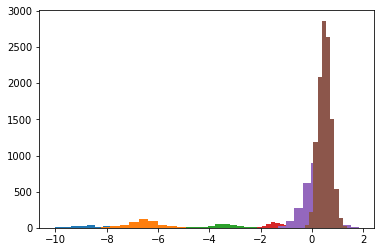

In [921]:
plt.hist(prova[0])
plt.hist(prova[1])
plt.hist(prova[2])
plt.hist(prova[3])
plt.hist(prova[4])
plt.hist(prova[5])
plt.hist(prova[6])
plt.show()

In [922]:
file_123 = r.TFile(file_name123, "READ")
pca_123 = file_123.Get(tup_name123)
info_pca.AddFriend(pca_123)

In [923]:
info_pca.Draw("tan>>Z2(50, 0, 1.)", "Z_c == 2", "colz")
Z2 = r.gDirectory.Get("Z2")
Z2_2 = Z2.GetEntries()

info_pca.Draw("tan>>Z3(50, 0, 1.)", "Z_c == 3", "colz")
Z3 = r.gDirectory.Get("Z3")
Z3_1 = Z3.GetEntries()

info_pca.Draw("tan>>Z4(50, 0, 1.)", "Z_c == 4", "colz")
Z4 = r.gDirectory.Get("Z4")
Z4_1 = Z4.GetEntries()

info_pca.Draw("tan>>Z5(50, 0, 1.)", "Z_c == 5", "colz")
Z5 = r.gDirectory.Get("Z5")
Z5_1 = Z5.GetEntries()

In [924]:
hs = r.THStack("hs2", "hs2")
#hs.Add(btan)
#hs.Add(Z1_tan)
hs.Add(Z2)
hs.Add(Z3)
hs.Add(Z4)
hs.Add(Z5)

hs.SetTitle("Angular Distribution; tan(#theta);Entries")
c = r.TCanvas()
hs.Draw("pfcnostack")

legend = r.TLegend(0.5,0.65,0.85,0.85)
legend.SetTextFont(0)
legend.SetTextSize(0.1)
legend.AddEntry(Z2, "#splitline{Z=2, Entries = "+str(Z2.GetEntries())+"}{Mean: "+ str(round(Z2.GetMean(), 2)) + ", RMS = "+str(round(Z2.GetRMS(),2))+"}")
legend.AddEntry(Z3, "#splitline{Z=3, Entries = "+str(Z3.GetEntries())+"}{Mean: "+ str(round(Z3.GetMean(), 2)) + ", RMS = "+str(round(Z3.GetRMS(),2))+"}")
legend.AddEntry(Z4, "#splitline{Z=4, Entries = "+str(Z4.GetEntries())+"}{Mean: "+ str(round(Z4.GetMean(), 2)) + ", RMS = "+str(round(Z4.GetRMS(),2))+"}")
legend.AddEntry(Z5, "#splitline{Z=5, Entries = "+str(Z5.GetEntries())+"}{Mean: "+ str(round(Z5.GetMean(), 2)) + ", RMS = "+str(round(Z5.GetRMS(),2))+"}")
legend.Draw("SAME")


c.Draw()

In [925]:
c = r.TCanvas()
info_pca.Draw("tan>>h1(50, 0 ,1)", "Z_c==2")
info_pca.Draw("tan>>h2(50, 0 ,1)", "Z_c==3")
info_pca.Draw("tan>>h3(50, 0 ,1)", "Z_c==4")
info_pca.Draw("tan>>h4(50, 0 ,1)", "VR123>-1.5 && VR123<-0.35")
#tracks_2.Draw("tan>>h4(50,0,1)", "k1>0 && k2 ==0 && k3==0 && VR0_av>11300")

h1 = r.gDirectory.Get("h1")
h1.SetFillColor(0)
h1.SetLineColor(2)
h1.SetLineWidth(2)


h2 = r.gDirectory.Get("h2")
h2.SetFillColor(0)
h2.SetLineColor(4)
h2.SetLineWidth(2)

h3 = r.gDirectory.Get("h3")
h3.SetFillColor(0)
h3.SetLineColor(6)
h3.SetLineWidth(2)

h4 = r.gDirectory.Get("h4")
h4.SetFillColor(0)
h4.SetLineColor(8)
h4.SetLineWidth(2)


In [926]:
c = r.TCanvas()
hs = r.THStack("hs", "")
hs.Add(h1)
hs.Add(h2)
hs.Add(h3)
hs.Add(h4)
#hs.Add(h5)
hs.SetTitle("Angular Distribution of VP_{123} tracks; tan(#theta); Entries")
hs.Draw("nostack")


legend = r.TLegend(0.55,0.55,0.9,0.9)
legend.SetTextFont(0)
legend.SetTextSize(0.1)
legend.AddEntry(h1, "#splitline{Z=3?, Entries = "+str(h1.GetEntries())+"}{Mean: "+ str(round(h1.GetMean(), 2)) + ", RMS = "+str(round(h1.GetRMS(),2))+"}")
legend.AddEntry(h2, "#splitline{Z=4?, Entries = "+str(h2.GetEntries())+"}{Mean: "+ str(round(h2.GetMean(), 2)) + ", RMS = "+str(round(h2.GetRMS(),2))+"}")
legend.AddEntry(h3, "#splitline{Z=5?, Entries = "+str(h3.GetEntries())+"}{Mean: "+ str(round(h3.GetMean(), 2)) + ", RMS = "+str(round(h3.GetRMS(),2))+"}")
legend.AddEntry(h4, "#splitline{Z=6?, Entries = "+str(h4.GetEntries())+"}{Mean: "+ str(round(h4.GetMean(), 2)) + ", RMS = "+str(round(h4.GetRMS(),2))+"}")
#legend.AddEntry(h5, "#splitline{He, Entries = "+str(h5.GetEntries())+"}{Mean: "+ str(round(h5.GetMean(), 2)) + ", RMS = "+str(round(h5.GetRMS(),2))+"}")
legend.Draw("SAME")



c.Draw()

In [927]:
c = r.TCanvas()
hs = r.THStack("hs", "")
hs.Add(h1)
hs.Add(h2)
hs.Add(h3)
#hs.Add(h4)
#hs.Add(h5)
hs.SetTitle("Angular Distribution of VP_{123} tracks; tan(#theta); Entries")
hs.Draw("nostack")


legend = r.TLegend(0.55,0.55,0.9,0.9)
legend.SetTextFont(0)
legend.SetTextSize(0.1)
legend.AddEntry(h1, "#splitline{Z=3?, Entries = "+str(h1.GetEntries())+"}{Mean: "+ str(round(h1.GetMean(), 2)) + ", RMS = "+str(round(h1.GetRMS(),2))+"}")
legend.AddEntry(h2, "#splitline{Z=4?, Entries = "+str(h2.GetEntries())+"}{Mean: "+ str(round(h2.GetMean(), 2)) + ", RMS = "+str(round(h2.GetRMS(),2))+"}")
legend.AddEntry(h3, "#splitline{Z=5?, Entries = "+str(h3.GetEntries())+"}{Mean: "+ str(round(h3.GetMean(), 2)) + ", RMS = "+str(round(h3.GetRMS(),2))+"}")
#legend.AddEntry(h4, "#splitline{Z=2, Entries = "+str(h4.GetEntries())+"}{Mean: "+ str(round(h4.GetMean(), 2)) + ", RMS = "+str(round(h4.GetRMS(),2))+"}")
#legend.AddEntry(h5, "#splitline{He, Entries = "+str(h5.GetEntries())+"}{Mean: "+ str(round(h5.GetMean(), 2)) + ", RMS = "+str(round(h5.GetRMS(),2))+"}")
legend.Draw("SAME")



c.Draw()

In [928]:
c = r.TCanvas()
info_pca.Draw("tan", "Z_c==3")
c.Draw()

In [929]:
c = r.TCanvas()
Z4.Draw()
c.Draw()

In [930]:
c = r.TCanvas()
info_pca.Draw("VR3_av", "Z_c==2")
c.Draw()

In [931]:
file_pca.Close()
file_pca_2.Close()
file_123.Close()

In [932]:
cond = " && k1>0 && k2>1 && k3<=1"
new_cut2 = frag_cut + cond

c = r.TCanvas()
tracks_2.Draw("tan", new_cut2, "COLZ")
c.Draw()

#### Richiesta Di Leva

In [933]:
file_pca = r.TFile("PCA_012.root", "RECREATE")

cond = " && k1>0 && k2>1 && k3>1"
new_cut2 = frag_cut + cond

campione_pca = tracks_2.CopyTree(new_cut2)
campione_pca.Write("pca")

file_pca.Close()

In [934]:
principal = r.TPrincipal(3, "ND")

file_pca = r.TFile("PCA_012.root", "READ")
info_pca = file_pca.Get("pca")

for track in info_pca:
    vr0, vr1, vr2 = track.VR0_av, track.VR1_av, track.VR2_av
    vrs = np.zeros(3)
    vrs[0] = vr0
    vrs[1] = vr1
    vrs[2] = vr2
    principal.AddRow(vrs)
    
principal.MakePrincipals()
principal.MakeCode()

Writing on file "pca.C" ... done


In [935]:
r.gSystem.Load("pca_C.so")
vr123s = []
for track in info_pca:
    vr2, vr3, vr0 = track.VR0_av, track.VR1_av, track.VR2_av
    vrs = np.zeros(3)
    vrs[0] = vr2
    vrs[1] = vr3
    vrs[2] = vr0
    princ = np.zeros(3)
    principal.X2P(vrs, princ)
    vr123s.append(princ)

vr123 = []
for i in vr123s:
    vr123.append(i[0])
    
file_pca.Close()

In [936]:
file_pca_2 = r.TFile("PCA3.root", "RECREATE")

pca_1 = r.TNtuple("pca_2", "", "VR012")

for i in range(len(vr123)):
    pca_1.Fill(vr123[i])
pca_1.Write("pca_012")

370

In [937]:
ff = r.TFile("123.root", "READ")
pp = ff.Get("123_c")

In [938]:
pp.AddFriend(pca_1)

In [939]:
c = r.TCanvas()

r.gStyle.SetOptStat(111)

pp.Draw("VR123:VR012>>che", "", "colz")

h_dl = r.gDirectory.Get("che")
h_dl.SetTitle("VP_{123} vs VP_{012} [k_{1}>0, k_{2}, k_{3}>1]; VP_{012}; VP_{123}")
h_dl.Draw("COLZ")

t1 = r.TText(-2., -8, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

c.Draw()

## Prova Classificazione VP012

In [940]:
file_pca = r.TFile("PCA_012.root", "RECREATE")

cond = " && k1>0 && k2>1"
new_cut2 = frag_cut + cond

campione_pca = tracks_2.CopyTree(new_cut2)
campione_pca.Write("pca")

file_pca.Close()

In [941]:
principal = r.TPrincipal(3, "ND")

file_pca = r.TFile("PCA_012.root", "READ")
info_pca = file_pca.Get("pca")

for track in info_pca:
    vr0, vr1, vr2 = track.VR0_av, track.VR1_av, track.VR2_av
    vrs = np.zeros(3)
    vrs[0] = vr0
    vrs[1] = vr1
    vrs[2] = vr2
    principal.AddRow(vrs)
    
principal.MakePrincipals()
principal.MakeCode()

Writing on file "pca.C" ... done


In [942]:
r.gInterpreter.ProcessLine('.L pca.C+')

0

Info in <ACLiC>: modified script has already been compiled and loaded
Info in <ACLiC>: it will be regenerated and reloaded!
Info in <TUnixSystem::ACLiC>: creating shared library /home/baronunix/Scripts/GSI3/pca_C.so
Warning in cling::IncrementalParser::CheckABICompatibility():
  Possible C++ standard library mismatch, compiled with __GLIBCXX__ '20220324'
  Extraction of runtime standard library version was: '20220421'


In [943]:
r.gSystem.Load("pca_C.so")
vr123s = []
for track in info_pca:
    vr2, vr3, vr0 = track.VR0_av, track.VR1_av, track.VR2_av
    vrs = np.zeros(3)
    vrs[0] = vr2
    vrs[1] = vr3
    vrs[2] = vr0
    princ = np.zeros(3)
    principal.X2P(vrs, princ)
    vr123s.append(princ)

vr123 = []
for i in vr123s:
    vr123.append(i[0])
    
file_pca.Close()

In [944]:
file_pca_2 = r.TFile("PCA3.root", "RECREATE")

pca_1 = r.TNtuple("pca_2", "", "VR012")

for i in range(len(vr123)):
    pca_1.Fill(vr123[i])
pca_1.Write("pca_012")

371

In [945]:
kn = r.TCanvas()
pca_1.Draw("VR012>>012(100, -10, 5.5)")

hi = r.gDirectory.Get("012")
hi.SetTitle("VP_{012} (k_{1}>0 & k_{2}>1); VP_{012}; Entries")
hi.Draw("")

g2 = r.TF1("g2", "gaus(0) + gaus(3) + gaus(6)", -10.5, 6.)
g2.SetParameters(120, -.5, .5, 60, -3.5, 0.2, 40, -1.7, 0.5)
hi.Fit("g2", "L","", -10., -1.2)
#c.Update()
hi.Draw("PE")


t1 = r.TText(-9., 1000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

legend = r.TLegend(0.15,0.7,0.4,0.85)
legend.SetTextFont(0)
legend.SetTextSize(0.04)
legend.AddEntry("Entries", "Entries = " + str(hi.GetEntries()), "" )
legend.AddEntry("chi2 / NDF", "#chi^{2} / NDF = " + str(round(g2.GetChisquare(), 2)) + " / " + str(g2.GetNDF()), "" )
legend.AddEntry("prob", "Prob = " + str(round(g2.GetProb(), 4)), "")
legend.Draw("SAME")

kn.SetLogy(1)

kn.Draw()

 FCN=40.6366 FROM MIGRAD    STATUS=CONVERGED    1985 CALLS        1986 TOTAL
                     EDM=6.9248e-07    STRATEGY= 1      ERROR MATRIX ACCURATE 
  EXT PARAMETER                                   STEP         FIRST   
  NO.   NAME      VALUE            ERROR          SIZE      DERIVATIVE 
   1  p0           1.03630e+03   1.76972e+03   2.14357e-01  -9.84822e-06
   2  p1           8.46472e+00   4.74039e+00   3.10493e-04   6.91006e-03
   3  p2           3.98808e+00   8.56915e-01   1.14976e-04  -1.94182e-02
   4  p3           3.85845e+01   2.76018e+00   9.73667e-03  -9.00046e-05
   5  p4          -6.17313e+00   4.78804e-02   1.56224e-04  -3.14911e-03
   6  p5           5.52221e-01   3.89516e-02   1.03378e-04  -2.52787e-03
   7  p6           5.91314e+01   4.23609e+00   1.47406e-02  -2.55346e-05
   8  p7          -4.48304e+00   3.22289e-02   1.18121e-04   8.48659e-03
   9  p8           4.05102e-01   2.85749e-02   8.21504e-05  -1.01412e-02
                               ERR DEF= 0.5

In [946]:
prova = make_classification_012(pca_1, g2, 3, -1.5)

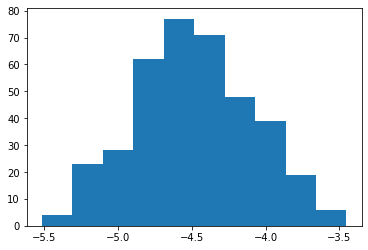

In [947]:
plt.hist(prova[2])
#plt.hist(prova[2])
plt.show()

In [948]:
file_pca = r.TFile("PCA_012.root", "READ")
info_pca = file_pca.Get("pca")
pca_1.AddFriend(info_pca)

kn = r.TCanvas()
pca_1.Draw("VR012>>k3_low", "k3<=1")

h4 = r.gDirectory.Get("k3_low")
h4.SetTitle("VP_{012} [k_{3}<=1];VP_{012};Entries")
h4.Draw()

kn.Draw()


In [949]:
file_pca.Close()

In [950]:
file_name012 = '012.root'
tup_name012 = '012_c'

In [951]:
prova2 = make_classification_012_X(pca_1, g2, file_name012, tup_name012, 3, -1.5, 2, 3, 4)

## Classificazione VP013

In [952]:
file_pca = r.TFile("PCA_013.root", "RECREATE")

cond = " && k1>0 && k3>1"
new_cut2 = frag_cut + cond

campione_pca = tracks_2.CopyTree(new_cut2)
campione_pca.Write("pca")

file_pca.Close()

In [953]:
principal = r.TPrincipal(3, "ND")

file_pca = r.TFile("PCA_013.root", "READ")
info_pca = file_pca.Get("pca")

for track in info_pca:
    vr0, vr1, vr2 = track.VR0_av, track.VR1_av, track.VR3_av
    vrs = np.zeros(3)
    vrs[0] = vr0
    vrs[1] = vr1
    vrs[2] = vr2
    principal.AddRow(vrs)
    
principal.MakePrincipals()
principal.MakeCode()

Writing on file "pca.C" ... done


In [954]:
r.gInterpreter.ProcessLine('.L pca.C+')

0

Info in <ACLiC>: modified script has already been compiled and loaded
Info in <ACLiC>: it will be regenerated and reloaded!
Info in <TUnixSystem::ACLiC>: creating shared library /home/baronunix/Scripts/GSI3/pca_C.so
Warning in cling::IncrementalParser::CheckABICompatibility():
  Possible C++ standard library mismatch, compiled with __GLIBCXX__ '20220324'
  Extraction of runtime standard library version was: '20220421'


In [955]:
r.gSystem.Load("pca_C.so")
vr123s = []
for track in info_pca:
    vr2, vr3, vr0 = track.VR0_av, track.VR1_av, track.VR3_av
    vrs = np.zeros(3)
    vrs[0] = vr2
    vrs[1] = vr3
    vrs[2] = vr0
    princ = np.zeros(3)
    principal.X2P(vrs, princ)
    vr123s.append(princ)

vr123 = []
for i in vr123s:
    vr123.append(i[0])
    
file_pca.Close()

In [956]:
file_pca_2 = r.TFile("PCA3.root", "RECREATE")

pca_1 = r.TNtuple("pca_2", "", "VR013")

for i in range(len(vr123)):
    pca_1.Fill(vr123[i])
pca_1.Write("pca_013")

369

In [957]:
kn = r.TCanvas()
pca_1.Draw("VR013>>013(100, -10, 5.5)")

hi = r.gDirectory.Get("013")
hi.SetTitle("VP_{013} (k_{1}>0 & k_{3}>1); VP_{013}; Entries")
hi.Draw("")

g2 = r.TF1("g2", "gaus(0) + gaus(3) + gaus(6)", -10.5, 6.)
g2.SetParameters(50, -6.5, .5, 50, -4.5, 0.5, 30, -2.5, 0.5)
hi.Fit("g2", "L","", -10., -2.)
#c.Update()
hi.Draw("PE")


t1 = r.TText(-9., 1000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")


legend = r.TLegend(0.15,0.7,0.4,0.85)
legend.SetTextFont(0)
legend.SetTextSize(0.04)
legend.AddEntry("Entries", "Entries = "+str(hi.GetEntries()), "" )
legend.AddEntry("chi2 / NDF", "#chi^{2} / NDF = " + str(round(g2.GetChisquare(), 2)) + " / " + str(g2.GetNDF()), "" )
legend.AddEntry("prob", "Prob = " + str(round(g2.GetProb(), 4)), "")
legend.Draw("SAME")

kn.SetLogy(1)

kn.Draw()

 FCN=18.4368 FROM MIGRAD    STATUS=CONVERGED     341 CALLS         342 TOTAL
                     EDM=4.88296e-08    STRATEGY= 1  ERROR MATRIX UNCERTAINTY   2.4 per cent
  EXT PARAMETER                                   STEP         FIRST   
  NO.   NAME      VALUE            ERROR          SIZE      DERIVATIVE 
   1  p0           2.46752e+01   2.03298e+00   6.36839e-04  -1.03559e-04
   2  p1          -6.84996e+00   5.32030e-02  -6.03647e-05  -3.65582e-03
   3  p2           4.76601e-01   3.78431e-02  -2.03197e-05  -1.23731e-03
   4  p3           5.54000e+01   3.49695e+00  -9.11262e-04   9.21551e-06
   5  p4          -5.04493e+00   3.20957e-02  -2.62119e-05   2.94617e-03
   6  p5           5.32844e-01   3.40890e-02   2.27989e-05  -5.25487e-03
   7  p6           3.57084e+01   2.98627e+00  -1.41936e-03   3.24524e-05
   8  p7          -2.64243e+00   4.72574e-02  -4.74076e-06  -1.53270e-03
   9  p8           5.36194e-01   6.05126e-02   5.34435e-06   1.67712e-03
                             

In [958]:
file_pca = r.TFile("PCA_013.root", "READ")
info_pca = file_pca.Get("pca")

pca_1.AddFriend(info_pca)

In [959]:
c = r.TCanvas()
pca_1.Draw("VR013", "k2<=1")
c.Draw()

In [960]:
def make_classification_013_X(PCA_tup, fit_func, file_name, tupname, N_gaus=4, tr=-1.5, Z0=2, Z1=3, Z2=4): 
    
    params = fit_func.GetParameters()
    file_pca2 = r.TFile(file_name, "RECREATE")
    low_value, high_value = 0., 0.
    
    pca_2 = r.TNtuple(tupname, "", "VR012:Z_013")
    Z_c = 0.
    cn_s = []
    for i in range(N_gaus+1):
        cn_s.append([])
        
    for track in PCA_tup:
        PCA_value = track.VR013
        
        if (PCA_value>tr):
            cn_s[-1].append(PCA_value)
            Z_c = 11
            pca_2.Fill(PCA_value, Z_c)
            continue
        
        random_number = np.random.uniform(0,1)
        probs = []
        for i in range(N_gaus):
            probs.append(g_func(PCA_value, params[0+int(3*i)], params[1+int(3*i)], params[2+int(3*i)])/fit_func.Eval(PCA_value) )
        o_ps = sorted(probs)
        indexes = []
        for p in probs:
            indexes.append(o_ps.index(p))
        
        if (random_number <= o_ps[0]):
            check = True
            pos = 0
            for j1 in range(len(indexes)):
                if (indexes[j1] == 0): 
                    pos = j1
            for j2 in range(len(indexes)):
                if (j2 != pos and indexes[j2] == 0):
                    check = False
            if (check):
                cn_s[pos].append(PCA_value)
                if (pos == 0):
                    Z_c = Z0
                elif (pos == 1):
                    Z_c = Z1
                elif (pos == 2):
                    Z_c = Z2
                
                
        for k in range(N_gaus-1):
            
            if (k == 0):
                low_value = o_ps[0]
            elif (k == 1):
                low_value = o_ps[0] + o_ps[k]
            elif (k == 2):
                low_value = high_value
            high_value = low_value + o_ps[k+1]
        
            if (k < N_gaus-2):
                if (random_number > low_value and random_number <= high_value):
                    check = True
                    pos = 0
                    for j1 in range(len(indexes)):
                        if (indexes[j1] == k+1): 
                            pos = j1
                    for j2 in range(len(indexes)):
                        if (j2 != pos and indexes[j2] == k+1):
                            check = False
                    if (check):
                        cn_s[pos].append(PCA_value)
                        if (pos == 0):
                    	    Z_c = Z0
                        elif (pos == 1):
                            Z_c = Z1
                        elif (pos == 2):
                            Z_c = Z2
                
            elif (k == N_gaus-2):  #funziona per N_gaus = 4
                if (random_number > low_value):
                    check = True
                    pos = 0
                    for j1 in range(len(indexes)):
                        if (indexes[j1] == k+1): 
                            pos = j1
                    for j2 in range(len(indexes)):
                        if (j2 != pos and indexes[j2] == k+1):
                            check = False
                    if (check):
                        cn_s[pos].append(PCA_value)
                        if (pos == 0):
                            Z_c = Z0
                        elif (pos == 1):
                            Z_c = Z1
                        elif (pos == 2):
                            Z_c = Z2
    
        
        pca_2.Fill(PCA_value, Z_c)     
    pca_2.Write(tupname)
    file_pca2.Close()
    return cn_s

In [961]:
file_name013 = '013.root'
tup_name013 = '013_c'

In [962]:
prova2 = make_classification_013_X(pca_1, g2, file_name013, tup_name013, 3, -1.5, 2, 3, 4)

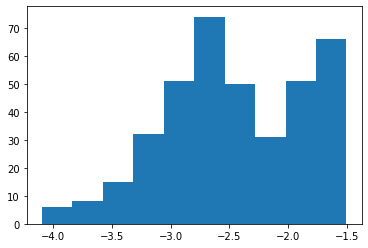

In [963]:
plt.hist(prova2[2])
plt.show()

## Classificazione VP01

In [964]:
r.gStyle.SetOptStat(111)

In [965]:
c = r.TCanvas()
tracks_2.Draw("VR1_av:VR0_av>>Z1_2v", frag_cut + " && k2<2 && k3<2 && k1>0 && VR1_av<7500", "colz")

z12 = r.gDirectory.Get("Z1_2v")
z12.SetTitle("VR1_{av} vs VR0_{av} [Lower Population];VR0_{av};VR1_{av}")
z12.Draw("COLZ")

x0, y0 = 11000, 3600
x1, y1 = 12300, 3250
b = (y1-y0)/(x1-x0)
a = y0-b*x0
cut_expr = str(a) + " " + str(b) + "*x"

cut = r.TF1("cut_eli", cut_expr, 9200, 15000)
cut.SetLineColor(2)
cut.SetLineWidth(5)
cut.SetLineStyle(2)
cut.Draw("SAME")

t1 = r.TText(6000, 5000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

c.Draw()

In [966]:
print(a)
print(b)

6561.538461538461
-0.2692307692307692


In [967]:
c = r.TCanvas()

below = "VR1_av < " + str(a) + " + " + str(b) + "* VR0_av" 
above = "VR1_av >= " + str(a) + " + " + str(b) + "* VR0_av" 

tracks_2.Draw("tan>>z1(100,0,1)", below + " && k1>0 && k2<2 && k3<2 && VR1_av<7500 && " + frag_cut, "colz")

h1 = r.gDirectory.Get("z1")
h1.SetTitle("tan(#theta) [Below Cut]; tan(#theta);Entries")

t1 = r.TText(0.8, 20, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

c.Draw()

In [968]:
c = r.TCanvas()
tracks_2.Draw("tan>>z2(100,0,1)", above + " && k1>0 && k2<2 && k3<2 && VR1_av<7500", "colz")

h1 = r.gDirectory.Get("z2")
h1.SetTitle("tan(#theta) [Above Cut]; tan(#theta);Entries")

t1 = r.TText(0.6, 250, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

c.Draw()

In [969]:
c = r.TCanvas()
tracks_2.Draw("s.W()", frag_cut + " && k1==0")
c.Draw()

In [970]:
c = r.TCanvas()
tracks_2.Draw("s.W()", frag_cut + " && k1>0 && k2<2 && k3<2")
c.Draw()

In [971]:
c = r.TCanvas()
tracks_2.Draw("s.W()", frag_cut + " && k1>0 && k2>=2 && k3>=2")
c.Draw()

In [972]:
file_pca = r.TFile("PCA_01.root", "RECREATE")

frag_cut = "VR0_av >= " + str(a2) + "*(1 + TMath::Exp(" + str(b2) + " *tan*tan))"

cond = " && k1>0 && k2<2 && k3<2 && VR1_av<7500"
new_cut2 = frag_cut + cond

campione_pca = tracks_2.CopyTree(new_cut2)
campione_pca.Write("pca")

file_pca.Close()

In [973]:
principal = r.TPrincipal(2, "ND")

file_pca = r.TFile("PCA_01.root", "READ")
info_pca = file_pca.Get("pca")

for track in info_pca:
    vr0, vr1 = track.VR0_av, track.VR1_av
    vrs = np.zeros(2)
    vrs[0] = vr0
    vrs[1] = vr1
    principal.AddRow(vrs)
    
principal.MakePrincipals()
principal.MakeCode()

Writing on file "pca.C" ... done


In [974]:
r.gInterpreter.ProcessLine('.L pca.C+')

0

Info in <ACLiC>: modified script has already been compiled and loaded
Info in <ACLiC>: it will be regenerated and reloaded!
Info in <TUnixSystem::ACLiC>: creating shared library /home/baronunix/Scripts/GSI3/pca_C.so
Warning in cling::IncrementalParser::CheckABICompatibility():
  Possible C++ standard library mismatch, compiled with __GLIBCXX__ '20220324'
  Extraction of runtime standard library version was: '20220421'


In [975]:
r.gSystem.Load("pca_C.so")
vr123s = []
for track in info_pca:
    vr2, vr3 = track.VR0_av, track.VR1_av
    vrs = np.zeros(2)
    vrs[0] = vr2
    vrs[1] = vr3
    princ = np.zeros(2)
    principal.X2P(vrs, princ)
    vr123s.append(princ)

vr123 = []
for i in vr123s:
    vr123.append(i[0])
    
file_pca.Close()

In [976]:
file_pca_2 = r.TFile("PCA3.root", "RECREATE")

pca_1 = r.TNtuple("pca_2", "", "VP01")

for i in range(len(vr123)):
    pca_1.Fill(vr123[i])
pca_1.Write("pca_01")

351

In [977]:
kn = r.TCanvas()
pca_1.Draw("VP01>>01(100, -6.5, 5.5)")

hi = r.gDirectory.Get("01")
hi.SetTitle("VP_{01} [Lower Population]; VP_{01}; Entries")
hi.Draw("")

t1 = r.TText(0.8, 20, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")


kn.Draw()

In [978]:
kn = r.TCanvas()
pca_1.Draw("VP01>>01(80, -6.5, 5.5)")

hi = r.gDirectory.Get("01")
hi.SetTitle("VP_{01} [Lower Population]; VP_{01}; Entries")
hi.Draw("")

g2 = r.TF1("g2", "gaus(0) + gaus(3)", -6.5, 6.)
g2.SetParameters(400, 0., .5, 30, -2, 1.)

#g2.SetParLimits(1, 0.2, .4)
g2.SetParLimits(4, -1.9, -1.8)

hi.Fit("g2", "L","", -1.4, 4.)
c.Update()
hi.Draw("PE")

params = g2.GetParameters()

comp1 = r.TF1("comp1", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 4.)
comp1.SetParameters(params[0], params[1], params[2])
comp1.SetLineColor(4)
comp1.Draw("SAME")

comp1_2 = r.TF1("comp1_2", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 4.)
comp1_2.SetParameters(params[3], params[4], params[5])
comp1_2.SetLineColor(2)
comp1_2.SetLineStyle(2)
comp1_2.Draw("SAME")


legend = r.TLegend(0.6,0.65,0.88,0.85)
legend.SetTextFont(0)
legend.SetTextSize(0.04)
legend.AddEntry("chi2 / NDF", "#chi^{2} / NDF = " + str(round(g2.GetChisquare(), 2)) + " / " + str(g2.GetNDF()) )
legend.AddEntry("prob", "Prob = " + str(round(g2.GetProb(), 5)))
legend.Draw("SAME")

kn.Draw()

 FCN=19.0484 FROM MIGRAD    STATUS=CONVERGED     430 CALLS         431 TOTAL
                     EDM=6.67773e-07    STRATEGY= 1      ERROR MATRIX ACCURATE 
  EXT PARAMETER                                   STEP         FIRST   
  NO.   NAME      VALUE            ERROR          SIZE      DERIVATIVE 
   1  p0           3.10887e+02   5.84728e+01   1.37228e-02   5.28066e-05
   2  p1          -6.85621e-02   1.65788e-01   5.98984e-05  -7.48472e-04
   3  p2           1.15287e+00   9.52319e-02   3.85493e-05   2.69883e-02
   4  p3           4.00414e+01   8.63753e+01   1.68696e-02   5.88412e-05
   5  p4          -1.80000e+00   6.24818e-02   6.50004e-02  -1.20131e-05
   6  p5           1.85638e+00   3.90802e-01   4.36697e-04   2.59685e-03
                               ERR DEF= 0.5


Info in <ROOT::Math::ParameterSettings>: lower/upper bounds outside current parameter value. The value will be set to (low+up)/2 


In [979]:
kn = r.TCanvas()
pca_1.Draw("VP01>>01(80, -6.5, 5.5)")

hi = r.gDirectory.Get("01")
hi.SetTitle("VP_{01} [Lower Population]; VP_{01}; Entries")
hi.Draw("")

g2 = r.TF1("g2", "gaus(0) + gaus(3)", -6.5, 6.)
g2.SetParameters(400, 0.47, .6, 30, -2, 1.)

#g2.SetParLimits(1, 0.2, .4)
g2.SetParLimits(4, -1.9, -1.8)

hi.Fit("g2", "L","", -6.5, 4.)
c.Update()
hi.Draw("PE")

params = g2.GetParameters()

comp1 = r.TF1("comp1", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 4.)
comp1.SetParameters(params[0], params[1], params[2])
comp1.SetLineColor(4)
comp1.Draw("SAME")

comp1_2 = r.TF1("comp1_2", "[0]*TMath::Gaus(x, [1], [2])", -10.5, 4.)
comp1_2.SetParameters(params[3], params[4], params[5])
comp1_2.SetLineColor(2)
comp1_2.SetLineStyle(2)
comp1_2.Draw("SAME")


legend = r.TLegend(0.6,0.65,0.88,0.85)
legend.SetTextFont(0)
legend.SetTextSize(0.04)
legend.AddEntry("chi2 / NDF", "#chi^{2} / NDF = " + str(round(g2.GetChisquare(), 2)) + " / " + str(g2.GetNDF()), "" )
legend.AddEntry("prob", "Prob = " + str(round(g2.GetProb(), 5)), "")
legend.Draw("SAME")

t1 = r.TText(0.8, 20, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

kn.Draw()

 FCN=108.673 FROM MIGRAD    STATUS=CONVERGED     300 CALLS         301 TOTAL
                     EDM=9.16443e-07    STRATEGY= 1  ERROR MATRIX UNCERTAINTY   0.8 per cent
  EXT PARAMETER                                   STEP         FIRST   
  NO.   NAME      VALUE            ERROR          SIZE      DERIVATIVE 
   1  p0           3.54525e+02   5.47402e+00  -1.76034e-02  -9.48084e-06
   2  p1           7.71173e-03   1.39887e-02   5.09742e-05   1.72797e-02
   3  p2           1.06623e+00   9.83391e-03   3.82065e-05  -1.61094e-02
   4  p3           5.42564e+01   9.56166e-01  -4.21830e-04  -6.68479e-05
   5  p4          -1.86074e+00   1.33015e-02  -3.49725e-03  -1.62822e-04
   6  p5          -4.71271e-02   8.89409e-03   1.73550e-05   1.54260e-01
                               ERR DEF= 0.5


Info in <ROOT::Math::ParameterSettings>: lower/upper bounds outside current parameter value. The value will be set to (low+up)/2 


In [980]:
prova = make_classification_01_X(pca_1, g2, '01.root', '01_c')

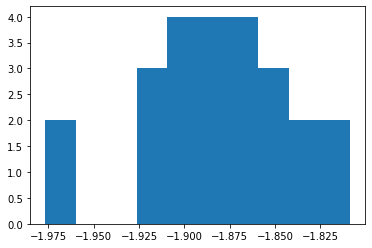

In [981]:
plt.hist(prova[1])
#plt.hist(prova[1])
plt.show()

In [982]:
prova = make_classification_01_X(pca_1, g2, '01.root', '01_c', 2, 1)

In [983]:
file_name01 = '01.root'
tup_name01 = '01_c'

In [984]:
file_pca01 = r.TFile(file_name01, "READ")
pca_01 = file_pca01.Get(tup_name01)

file_info_pca01 = r.TFile("PCA_01.root", "READ")
info_pca01 = file_info_pca01.Get("pca")

pca_01.AddFriend(info_pca01)

c = r.TCanvas()
pca_01.Draw("tanf>>lez1(100,0,1)", "Z_c==2")

h1 = r.gDirectory.Get("lez1")
h1.SetTitle("tan(#theta) [Z = 1 from VP_{01}];tan(#theta);Entries")
h1.Draw()

c.Draw()

In [985]:
c = r.TCanvas()
pca_01.Draw("tanf>>lez1(100,0,1)", "Z_c==1")

h1 = r.gDirectory.Get("lez1")
h1.SetTitle("tan(#theta) [Z = 2 from VP_{01}];tan(#theta);Entries")
h1.Draw()

c.Draw()

In [986]:
c = r.TCanvas()
pca_01.Draw("VR1_av:VR0_av>>z2(100,0,1)", "Z_c==1")

h1 = r.gDirectory.Get("z2")
h1.SetTitle("VR1_{av} vs VR0_{av} [Z = 2 from VP_{01}];VR0_{av};VR1_{av}")
h1.Draw("colz")

t1 = r.TText(8000, 3000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

c.Draw()

In [987]:
c = r.TCanvas()
pca_01.Draw("VR1_av:VR0_av>>z1(100,0,1)", "Z_c==2")

h1 = r.gDirectory.Get("z1")
h1.SetTitle("VR1_{av} vs VR0_{av} [Z = 1 from VP_{01}];VR0_{av};VR1_{av}")
h1.Draw("colz")

t1 = r.TText(8000, 3000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")


c.Draw()

In [988]:
file_pca01.Close()
file_info_pca01.Close()

In [989]:
file_pca.Close()
file_pca_2.Close()

In [990]:
frag_cut = "VR0_av >= " + str(a2) + "*(1 + TMath::Exp(" + str(b2) + " *tan*tan))"

In [991]:
file2 = r.TFile(file_name_cuts, "READ")

tracks_2 = file2.Get("tracks_cuts")

In [992]:
c = r.TCanvas()
tracks_2.Draw("VR0_av:tan>>hss", frag_cut + " && k1>0 && k3>1 && k2<=1", "colz")
c.Draw()

## Scrittura Z in Output

In [993]:
file_name01 = '01.root'
tup_name01 = '01_c'
file_name012 = '012.root'
tup_name012 = '012_c'
file_name123 = '123.root'
tup_name123 = '123_c'
file_name013 = '013.root'
tup_name013 = '013_c'

In [994]:
file = r.TFile(track_name, "READ")
tracks = file.Get("tracks")

In [995]:
## Definizione tree in uscita

file_out = r.TFile("output_b333n.root", "RECREATE")

Z_rec = np.zeros(1, dtype = np.intc)

output_tree = tracks.CloneTree(0)

#tracks.SetBranchAddress("n0", Z_rec)
output_tree.Branch("Z", Z_rec, "Z/I")

tracks.BuildIndex("trid")

131027

In [996]:
## tree con variabili di volume

nseg0 = np.zeros(1, dtype = np.intc)
nseg1 = np.zeros(1, dtype = np.intc)
nseg2 = np.zeros(1, dtype = np.intc)
nseg3 = np.zeros(1, dtype = np.intc)

volume0 = np.zeros(1, dtype = np.double)
volume1 = np.zeros(1, dtype = np.double)
volume2 = np.zeros(1, dtype = np.double)
volume3 = np.zeros(1, dtype = np.double)


output_tree2 = tracks.CloneTree(0)
output_tree2.Branch("VR0_av", volume0, "VR0_av/D")
output_tree2.Branch("VR1_av", volume1, "VR1_av/D")
output_tree2.Branch("VR2_av", volume2, "VR2_av/D")
output_tree2.Branch("VR3_av", volume3, "VR3_av/D")

output_tree2.Branch("k0", nseg0, "k0/I")
output_tree2.Branch("k1", nseg1, "k1/I")
output_tree2.Branch("k2", nseg2, "k2/I")
output_tree2.Branch("k3", nseg3, "k3/I")

output_tree2.Branch("Z", Z_rec, "Z/I")


In [997]:
for i in range(tracks.GetEntries()):
    tracks.GetEntry(i)
    k0, k1, k2, k3 = 0, 0, 0, 0
    VR0av, VR1av, VR2av, VR3av = 0, 0, 0, 0
    vr0, vr1, vr2, vr3 = 0, 0, 0, 0
    for s in tracks.s:
        if((s.Plate()-31)%4 - 0 == 0):
            k0+=1
            vr0 += s.Volume()
        if((s.Plate()-31)%4 - 1 == 0):
            k1+=1
            vr1 += s.Volume()   
        if((s.Plate()-31)%4 - 2 == 0):
            k2+=1
            vr2 += s.Volume()
        if((s.Plate()-31)%4 - 3 == 0):
            k3+=1
            vr3 += s.Volume()      
    if(k0!=0):
            VR0av = vr0/k0
    if(k1!=0):
            VR1av = vr1/k1
    if(k2!=0):
            VR2av = vr2/k2
    if(k3!=0):
            VR3av = vr3/k3
            
    nseg0[0], nseg1[0], nseg2[0], nseg3[0] = k0, k1, k2, k3
    volume0[0], volume1[0], volume2[0], volume3[0] = VR0av, VR1av, VR2av, VR3av
    
    if (k0<4 or VR0av>=25000):
        Z_rec[0] = -1
        
        output_tree.Fill()
        output_tree2.Fill()

In [998]:
count = 0
g1, g2, g3, g4, g5, g6, g7 = 0, 0, 0, 0, 0, 0, 0
for i in range(tracks_2.GetEntries()):
    tracks_2.GetEntry(i)
    tracks.GetEntry(tracks_2.trid)
    frag_cut = (tracks_2.VR0_av > a2*(1 + np.exp(b2 * tracks_2.tan*tracks_2.tan)))
    cond1 = (tracks_2.k2 <=1 and tracks_2.k3<=1)
    cond2 = tracks_2.VR1_av>0
    cond3 = tracks_2.VR1_av>6000
    cond0 = tracks_2.VR1_av == 0
    cond4 = tracks_2.k2 == 0
    cond_vp123 = tracks_2.k1>0 and tracks_2.k2>1 and tracks_2.k3>1
    cond_vp012 = tracks_2.k1>0 and tracks_2.k2>1 and tracks_2.k3<=1
    cond_vp013 = tracks_2.k1>0 and tracks_2.k2<=1 and tracks_2.k3>1
    
    nseg0[0], nseg1[0], nseg2[0], nseg3[0] = tracks_2.k0, tracks_2.k1, tracks_2.k2, tracks_2.k3
    volume0[0], volume1[0], volume2[0], volume3[0] = tracks_2.VR0_av, tracks_2.VR1_av, tracks_2.VR2_av, tracks_2.VR3_av
    
    if ((i%10000)==0):
        print("Carica Assegnata a " + str(round(count,2)) + " tracce, su " + str(tracks_2.GetEntries()))
    if (frag_cut and cond0):
        Z_rec[0] = 1
        output_tree.Fill()
        output_tree2.Fill()
        count = count + 1
        g1 = g1 + 1
    elif (frag_cut and cond1 and cond2 and tracks_2.VR1_av<7500):
        #Z_rec[0] = 2
        #print("Z= "+str(Z_rec))
        #output_tree.Fill()
        #count = count + 1
        g2 = g2 + 1 
        continue
    elif (frag_cut and cond1 and cond2 and tracks_2.VR1_av>7500):
        Z_rec[0] = 11 
        #print("Z= "+str(Z_rec))
        output_tree.Fill()
        output_tree2.Fill()
        count = count + 1
        g3 = g3 +1
    #elif (frag_cut and cond4 and cond2):
        #Z_rec[0] = 1
        #output_tree.Fill()
        #count = count + 1
    elif (not frag_cut):
        Z_rec[0] = -1
        #print("Z=" +str(Z_rec))
        output_tree.Fill()
        output_tree2.Fill()
        count = count + 1
        g4 = g4 + 1
    elif (cond_vp123):
        g5 = g5 + 1
        continue
    elif (cond_vp012):
        g6 = g6 + 1
        continue
    elif (cond_vp013):
        g7 = g7 +1
        continue
    else:
        Z_rec[0] = 10
        output_tree.Fill()
        output_tree2.Fill()
    if (count == 0):
        print("Errore")
    #print("count= " + str(count))
print(g1, g2, g3, g4, g5 ,g6, g7)   

Carica Assegnata a 0 tracce, su 104668
Carica Assegnata a 7824 tracce, su 104668
Carica Assegnata a 14699 tracce, su 104668
Carica Assegnata a 20916 tracce, su 104668
Carica Assegnata a 25863 tracce, su 104668
Carica Assegnata a 34379 tracce, su 104668
Carica Assegnata a 44092 tracce, su 104668
Carica Assegnata a 53408 tracce, su 104668
Carica Assegnata a 62785 tracce, su 104668
Carica Assegnata a 71409 tracce, su 104668
Carica Assegnata a 80403 tracce, su 104668
18904 6352 555 64650 13556 408 243


In [999]:
file_pca01 = r.TFile(file_name01, "READ")
pca_3 = file_pca01.Get(tup_name01)

file_info_pca01 = r.TFile("PCA_01.root", "READ")
info_pca01 = file_info_pca01.Get("pca")

pca_3.AddFriend(info_pca01)
tracks_2.BuildIndex("trid", "npl")
count2 = 0
m1, m2 = 0, 0

for track_123 in pca_3:
    
    trid_to_assign, npl_to_assign = track_123.trid, track_123.npl
    tracks_2.GetEntryWithIndex(trid_to_assign, npl_to_assign)
    tracks.GetEntry(tracks_2.trid)
    
    #check0 = track_123.k2>1 and track_123.k3>1
    check1 = track_123.tan == tracks_2.tan and track_123.k0 == tracks_2.k0 and track_123.VR0_av == tracks_2.VR0_av
    check2 = track_123.k1 == tracks_2.k1 and track_123.VR1_av == tracks_2.VR1_av
    check3 = track_123.k2 == tracks_2.k2 and track_123.VR2_av == tracks_2.VR2_av
    check4 = track_123.k3 == tracks_2.k3 and track_123.VR3_av == tracks_2.VR3_av
    check5 = track_123.nseg == tracks_2.nseg and track_123.npl == tracks_2.npl
    check = check1 and check2 and check3 and check4 and check5
    
    nseg0[0], nseg1[0], nseg2[0], nseg3[0] = tracks_2.k0, tracks_2.k1, tracks_2.k2, tracks_2.k3
    volume0[0], volume1[0], volume2[0], volume3[0] = tracks_2.VR0_av, tracks_2.VR1_av, tracks_2.VR2_av, tracks_2.VR3_av
    
    if (check):
        if (int(track_123.Z_c == 1)):
            Z_rec[0] = 2 #sono invertiti in questa classificazione
            #print(Z_rec)
            output_tree.Fill()
            output_tree2.Fill()
            m2 = m2 + 1
            count2 = count2 +1
        elif(int(track_123.Z_c == 2) ):
            Z_rec[0] = 1  #sono invertiti in questa classificazione
            #print(Z_rec)
            output_tree.Fill()
            output_tree2.Fill()
            m1 = m1 +1 
            count2 = count2 +1
    #if (count == 0):
        #print("Error")
        #break
    
    if (count2%1000 == 0):
        print("Carica assegnata a " + str(count2+count) + " tracce, su " + str(tracks_2.GetEntries()))
file_pca01.Close()
file_info_pca01.Close()
print("100%")
print(count2)
print(m1, m2)

Carica assegnata a 85109 tracce, su 104668
Carica assegnata a 86109 tracce, su 104668
Carica assegnata a 87109 tracce, su 104668
Carica assegnata a 88109 tracce, su 104668
Carica assegnata a 89109 tracce, su 104668
Carica assegnata a 90109 tracce, su 104668
100%
6352
36 6316


In [1000]:
file_pca123 = r.TFile(file_name123, "READ")
pca_3 = file_pca123.Get(tup_name123)

file_info_pca123 = r.TFile("PCA_123.root", "READ")
info_pca123 = file_info_pca123.Get("pca")

pca_3.AddFriend(info_pca123)
tracks_2.BuildIndex("trid", "npl")
count3 = 0

for track_123 in pca_3:
    
    trid_to_assign, npl_to_assign = track_123.trid, track_123.npl
    tracks_2.GetEntryWithIndex(trid_to_assign, npl_to_assign)
    tracks.GetEntry(tracks_2.trid)
    
    check0 = track_123.k2>1 and track_123.k3>1
    check1 = track_123.tan == tracks_2.tan and track_123.k0 == tracks_2.k0 and track_123.VR0_av == tracks_2.VR0_av
    check2 = track_123.k1 == tracks_2.k1 and track_123.VR1_av == tracks_2.VR1_av
    check3 = track_123.k2 == tracks_2.k2 and track_123.VR2_av == tracks_2.VR2_av
    check4 = track_123.k3 == tracks_2.k3 and track_123.VR3_av == tracks_2.VR3_av
    check5 = track_123.nseg == tracks_2.nseg and track_123.npl == tracks_2.npl
    check = check1 and check2 and check3 and check4 and check5 and check0
    
    nseg0[0], nseg1[0], nseg2[0], nseg3[0] = tracks_2.k0, tracks_2.k1, tracks_2.k2, tracks_2.k3
    volume0[0], volume1[0], volume2[0], volume3[0] = tracks_2.VR0_av, tracks_2.VR1_av, tracks_2.VR2_av, tracks_2.VR3_av
    
    if (check):
        Z_rec[0] = int(track_123.Z_c)
        #print(Z_rec)
        output_tree.Fill()
        output_tree2.Fill()
        count3 = count3 +1
    #if (count == 0):
        #print("Error")
        #break
    
    if (count3%1000 == 0):
        print("Carica assegnata a " + str(count2+count+count3) + " tracce, su " + str(tracks_2.GetEntries()))
file_pca123.Close()
file_info_pca123.Close()
print("100%")
print(count3)

Carica assegnata a 91461 tracce, su 104668
Carica assegnata a 92461 tracce, su 104668
Carica assegnata a 93461 tracce, su 104668
Carica assegnata a 94461 tracce, su 104668
Carica assegnata a 95461 tracce, su 104668
Carica assegnata a 96461 tracce, su 104668
Carica assegnata a 97461 tracce, su 104668
Carica assegnata a 98461 tracce, su 104668
Carica assegnata a 99461 tracce, su 104668
Carica assegnata a 100461 tracce, su 104668
Carica assegnata a 101461 tracce, su 104668
Carica assegnata a 102461 tracce, su 104668
Carica assegnata a 103461 tracce, su 104668
100%
13556


In [1001]:
file_pca012 = r.TFile(file_name012, "READ")
pca_012 = file_pca012.Get(tup_name012)

file_info_pca012 = r.TFile("PCA_012.root", "READ")
info_pca012 = file_info_pca012.Get("pca")

pca_012.AddFriend(info_pca012)
#tracks_2.BuildIndex("trid", "npl")
count4 = 0

for track_012 in pca_012:
    
    countx = 0
    if (track_012.k2 > 1 and track_012.k3<=1):
        trid_to_assign, npl_to_assign = track_012.trid, track_012.npl
        tracks_2.GetEntryWithIndex(trid_to_assign, npl_to_assign)
        tracks.GetEntry(tracks_2.trid)
    
        check1 = track_012.tan == tracks_2.tan and track_012.k0 == tracks_2.k0 and track_012.VR0_av == tracks_2.VR0_av
        check2 = track_012.k1 == tracks_2.k1 and track_012.VR1_av == tracks_2.VR1_av
        check3 = track_012.k2 == tracks_2.k2 and track_012.VR2_av == tracks_2.VR2_av
        check4 = track_012.k3 == tracks_2.k3 and track_012.VR3_av == tracks_2.VR3_av
        check5 = track_012.nseg == tracks_2.nseg and track_012.npl == tracks_2.npl
        check = check1 and check2 and check3 and check4 and check5
        
        nseg0[0], nseg1[0], nseg2[0], nseg3[0] = tracks_2.k0, tracks_2.k1, tracks_2.k2, tracks_2.k3
        volume0[0], volume1[0], volume2[0], volume3[0] = tracks_2.VR0_av, tracks_2.VR1_av, tracks_2.VR2_av, tracks_2.VR3_av
        
        if (check and track_012.VR2_av < 8000):
            Z_rec[0] = int(track_012.Z_012) 
            #print(Z_rec)
            output_tree.Fill()
            output_tree2.Fill()
            countx = countx + 1
            count4 = count4 +1
        elif (check and track_012.VR2_av > 8000):
            Z_rec[0] = 11
            #print(Z_rec)
            output_tree.Fill()
            output_tree2.Fill()
            countx = countx + 1
            count4 = count4 +1
        #if (count == 0):
            #print("Error")
            #break
        
        if (count4%100 == 0):
           print("Carica assegnata a " + str(count2+count+count3+count4) + " tracce, su " + str(tracks_2.GetEntries()))
file_pca012.Close()
file_info_pca012.Close()
print("100%")
print(count4)

Carica assegnata a 104117 tracce, su 104668
Carica assegnata a 104217 tracce, su 104668
Carica assegnata a 104317 tracce, su 104668
Carica assegnata a 104417 tracce, su 104668
100%
408


In [1002]:
print(count+count2+count3+count4)
print(tracks_2.GetEntries())

104425
104668


In [1003]:
file_pca013 = r.TFile(file_name013, "READ")
pca_013 = file_pca013.Get(tup_name013)

file_info_pca013 = r.TFile("PCA_013.root", "READ")
info_pca013 = file_info_pca013.Get("pca")

pca_013.AddFriend(info_pca013)
#tracks_2.BuildIndex("trid", "npl")
count5 = 0

for track_012 in pca_013:
    
    if (track_012.k3 > 1 and track_012.k2<=1):
        trid_to_assign, npl_to_assign = track_012.trid, track_012.npl
        tracks_2.GetEntryWithIndex(trid_to_assign, npl_to_assign)
        tracks.GetEntry(tracks_2.trid)
    
        check1 = track_012.tan == tracks_2.tan and track_012.k0 == tracks_2.k0 and track_012.VR0_av == tracks_2.VR0_av
        check2 = track_012.k1 == tracks_2.k1 and track_012.VR1_av == tracks_2.VR1_av
        check3 = track_012.k2 == tracks_2.k2 and track_012.VR2_av == tracks_2.VR2_av
        check4 = track_012.k3 == tracks_2.k3 and track_012.VR3_av == tracks_2.VR3_av
        check5 = track_012.nseg == tracks_2.nseg and track_012.npl == tracks_2.npl
        check = check1 and check2 and check3 and check4 and check5
        
        nseg0[0], nseg1[0], nseg2[0], nseg3[0] = tracks_2.k0, tracks_2.k1, tracks_2.k2, tracks_2.k3
        volume0[0], volume1[0], volume2[0], volume3[0] = tracks_2.VR0_av, tracks_2.VR1_av, tracks_2.VR2_av, tracks_2.VR3_av
        
        if (check):
            Z_rec[0] = int(track_012.Z_013)
            #print(Z_rec)
            output_tree.Fill()
            output_tree2.Fill()
            count5 = count5 +1
        elif (check and track_012.VR2_av > 10000):
            Z_rec[0] = 11
            #print(Z_rec)
            output_tree.Fill()
            output_tree2.Fill()
            count5 = count5 +1
        #if (count == 0):
            #print("Error")
            #break
        
        #if (count5%100 == 0):
           #print("Carica assegnata a " + str(count2+count+count3+count4+count5) + " tracce, su " + str(tracks_2.GetEntries()))
file_pca013.Close()
file_info_pca013.Close()
print("100%")
print(count5)

100%
243


In [1004]:
file_out.cd()
#output_tree.Write("tracks")
output_tree2.Write("tracks")   #con info su VRi_av e ki
file_out.Close()

## Plot Opzionali

In [1005]:
file_out2 = r.TFile("output_b333n.root", "READ")
output_tree = file_out2.Get("tracks")

output_tree.Draw("s[0].Theta()>>Z5(50)", "Z != 0 && Z<10")
h4 = r.gDirectory.Get("Z5")
N2 = h4.GetEntries()
print(N2)

188406.0


In [1006]:
c = r.TCanvas()

output_tree.Draw("s[0].Theta()>>Z1(100, 0, 1)", "Z == 1")
hs = r.THStack("h4s", "")
h1 = r.gDirectory.Get("Z1")
hs.Add(h1)

output_tree.Draw("s[0].Theta()>>Z2(100, 0, 1)", "Z == 2")
h2 = r.gDirectory.Get("Z2")
hs.Add(h2)

output_tree.Draw("s[0].Theta()>>Z3(100, 0, 1)", "Z == 3")
h3 = r.gDirectory.Get("Z3")
hs.Add(h3)

output_tree.Draw("s[0].Theta()>>Z4(100, 0, 1)", "Z == 4")
h4 = r.gDirectory.Get("Z4")
hs.Add(h4)

output_tree.Draw("s[0].Theta()>>Z5(100, 0, 1)", "Z == 5")
h5 = r.gDirectory.Get("Z5")
hs.Add(h5)

hs.SetTitle("Fragments Angular Distribution GSI3 (k_{0}>=" + str(k0_min)+"); tan(#theta); Entries")
hs.Draw("pfc nostack")

legend = r.TLegend(0.55,0.6,0.9,0.9)
legend.SetTextFont(0)
legend.SetTextSize(0.1)

def lazy(histo, N):
    return "Entries = "+str(histo.GetEntries()) + " (" + str(round(100*histo.GetEntries()/N, 1)) + "%)}{Mean: "+ str(round(histo.GetMean(), 2)) + ", RMS = "+str(round(histo.GetRMS(),2))+"}"

#N = 34881.0

legend.AddEntry(h1, "#splitline{Z=1, " + lazy(h1, N2))
legend.AddEntry(h2, "#splitline{Z=2, "+ lazy(h2, N2))
legend.AddEntry(h3, "#splitline{Z=3, "+ lazy(h3, N2))
legend.AddEntry(h4, "#splitline{Z==4, "+ lazy(h4, N2))
legend.AddEntry(h5, "#splitline{Z==5, "+ lazy(h5, N2))
legend.Draw("SAME")

c.Draw()

In [1007]:
r.gStyle.SetOptStat(1)
c = r.TCanvas()
output_tree.Draw("tanf>>Z6(100, 0, 1)", "Z == 6")
h5 = r.gDirectory.Get("Z6")
h5.SetTitle("Angular Distribution [Z>=6]; tan(#theta);Entries")
h5.Draw()
c.Draw()

AttributeError: 'TObject' object has no attribute 'SetTitle'

Error in <TTreeFormula::Compile>:  Bad numerical expression : "tanf"
Info in <TSelectorDraw::AbortProcess>: Variable compilation failed: {tanf,Z == 6}


In [ ]:
c = r.TCanvas()
output_tree.Draw("Z", "")
c.Draw()

In [ ]:
tracks_2.GetEntries()

In [ ]:
output_tree.Draw("tan>>Z5(50)", "Z != 0 && Z<10")
h4 = r.gDirectory.Get("Z5")
N2 = h4.GetEntries()
print(N2)

In [ ]:
936/N2

In [ ]:
c2 = r.TCanvas()
output_tree.Draw("VR1_av:VR0_av>>hp(50, 5000, 2000, 50, 1000, 7000)", "Z==2", "colz")
c2.Draw()

In [ ]:
c2 = r.TCanvas()
output_tree.Draw("tanf>>z1(100, 0, 1)", "Z==1 && VR1_av>0", "colz")

z1 = r.gDirectory.Get("z1")
z1.SetTitle("Angular Distribution (Z=1 low energy);tan(#theta);Entries")

c2.Draw()

In [ ]:
c2 = r.TCanvas()

hs2 = r.THStack("h5s", "")

output_tree.Draw("VR3_av>>Z2r(100)", "Z == 2 && k3>0")
h1 = r.gDirectory.Get("Z2r")
hs2.Add(h1)

output_tree.Draw("VR3_av>>Z3r(100)", "Z == 3")
h3 = r.gDirectory.Get("Z3r")
hs2.Add(h3)

output_tree.Draw("VR3_av>>Z4r(100)", "Z == 4")
h2 = r.gDirectory.Get("Z4r")
hs2.Add(h2)

output_tree.Draw("VR3_av>>Z5r(100)", "Z == 5")
h5 = r.gDirectory.Get("Z5r")
hs2.Add(h5)

hs2.SetTitle("Distribuzione VR3_{av} dei Frammenti; VR3_{av}; Conteggi")
hs2.Draw("pfc nostack")

legend = r.TLegend(0.55,0.6,0.9,0.9)
legend.SetTextFont(0)
legend.SetTextSize(0.1)
legend.AddEntry(h1, "#splitline{Z=2, " + lazy(h1, N2))
legend.AddEntry(h3, "#splitline{Z=3, "+ lazy(h3, N2))
legend.AddEntry(h2, "#splitline{Z=4, "+ lazy(h2, N2))
legend.AddEntry(h5, "#splitline{Z=5, "+ lazy(h5, N2))
legend.Draw("SAME")



c2.Draw()

In [ ]:
c2 = r.TCanvas()

hs2 = r.THStack("h5s", "")

output_tree.Draw("VR2_av>>Z2r(100)", "Z == 2 && k2>0")
h1 = r.gDirectory.Get("Z2r")
hs2.Add(h1)

output_tree.Draw("VR2_av>>Z3r(100)", "Z == 3")
h3 = r.gDirectory.Get("Z3r")
hs2.Add(h3)

output_tree.Draw("VR2_av>>Z4r(100)", "Z == 4")
h2 = r.gDirectory.Get("Z4r")
hs2.Add(h2)

output_tree.Draw("VR2_av>>Z5r(100)", "Z == 5")
h5 = r.gDirectory.Get("Z5r")
hs2.Add(h5)

hs2.SetTitle("Distribuzione VR2_{av} dei Frammenti; VR2_{av}; Conteggi")
hs2.Draw("pfc nostack")

legend = r.TLegend(0.55,0.6,0.9,0.9)
legend.SetTextFont(0)
legend.SetTextSize(0.1)
legend.AddEntry(h1, "#splitline{Z=2, " + lazy(h1, N2))
legend.AddEntry(h3, "#splitline{Z=3, "+ lazy(h3, N2))
legend.AddEntry(h2, "#splitline{Z=4, "+ lazy(h2, N2))
legend.AddEntry(h5, "#splitline{Z=5, "+ lazy(h5, N2))
legend.Draw("SAME")



c2.Draw()

In [ ]:
file_out.Close()

In [ ]:
file_pca123 = r.TFile(file_name123, "READ")
pca_3 = file_pca123.Get(tup_name123)

file_info_pca123 = r.TFile("PCA_123.root", "READ")
info_pca123 = file_info_pca123.Get("pca")
pca_3.AddFriend(info_pca123)

c = r.TCanvas()
pca_3.Draw("VR123", "Z_c == 4")
c.Draw()

file_pca123.Close()
file_info_pca123.Close()

#### Controlli PCA01

In [ ]:
file_pca01 = r.TFile(file_name01, "READ")
pca_3 = file_pca01.Get(tup_name01)

file_info_pca01 = r.TFile("PCA_01.root", "READ")
info_pca01 = file_info_pca01.Get("pca")

pca_3.AddFriend(info_pca01)

c = r.TCanvas()
pca_3.Draw("tan>>z2(100,0,1)", "Z_c == 1")
pca_3.Draw("tan>>z1(100,0,1)", "Z_c == 2")

z2 = r.gDirectory.Get("z2")
#z2.Scale(1./z2.Integral(), "width")
z1 = r.gDirectory.Get("z1")
#z1.Scale(1./z1.Integral(), "width")

z1.SetFillColor(0)
z1.SetLineColor(2)
z1.SetLineWidth(2)

z2.SetFillColor(0)
z2.SetLineColor(4)
z2.SetLineWidth(2)

z12 = r.THStack("z12", "z12")
z12.SetTitle("Angular Distributions [VP_{01} tracks];tan(#theta);Entries")
z12.Add(z1)
z12.Add(z2)

legend = r.TLegend(0.55,0.55,0.9,0.9)
legend.SetTextFont(0)
legend.SetTextSize(0.1)
legend.AddEntry(z1, "#splitline{Z=1, Entries = "+str(z1.GetEntries())+"}{Mean: "+ str(round(z1.GetMean(), 2)) + ", RMS = "+str(round(z1.GetRMS(),2))+"}")
legend.AddEntry(z2, "#splitline{Z=2, Entries = "+str(z2.GetEntries())+"}{Mean: "+ str(round(z2.GetMean(), 2)) + ", RMS = "+str(round(z2.GetRMS(),2))+"}")

z12.Draw("nostack")
legend.Draw("SAME")
c.Draw()

In [ ]:
z2.SetTitle("Z = 2 Angular Distribution (k_{0}>=4);tan(#theta);Entries")
z2.Scale(1./z2.Integral())
z2.Draw()
c.Draw()

In [ ]:
print(z2.Integral())

In [ ]:
tracks_V.Draw("tanf>>Z2(100, 0, 1)", "s[0].W()-70 == 2 && k0>=4")
c.Draw()

In [ ]:
file_pca01.Close()
file_info_pca01.Close()

#### Controlli PCA 123

In [ ]:
file_pca123 = r.TFile(file_name123, "READ")
pca_3 = file_pca123.Get(tup_name123)

file_info_pca123 = r.TFile("PCA_123.root", "READ")
info_pca123 = file_info_pca123.Get("pca")

pca_3.AddFriend(info_pca123)

c = r.TCanvas()
pca_3.Draw("VR123", "VR123<-5.4")
c.Draw()

In [ ]:
c = r.TCanvas()
pca_3.Draw("VR123b")
c.Draw()

In [ ]:
c = r.TCanvas()
pca_3.Draw("VR123>>h(100, -8, 0.2)", "")
c.Draw()

In [ ]:
c = r.TCanvas()
pca_3.Draw("VR123>>h(100, -8, 2)", "k2>1 && k3>1")
c.SetLogy()
c.Draw()

In [ ]:
c = r.TCanvas()
pca_3.Draw("k1+k2", "k2>1 && k3>1 && VR123<-5")
c.Draw()

In [ ]:
c = r.TCanvas()
pca_3.Draw("k1+k2", "k2>1 && k3>1 && VR123>-5")
c.Draw()

In [ ]:
c = r.TCanvas()
pca_3.Draw("tanf>>z5_123(50, 0, 0.2)", "Z_c == 5")

r.gStyle.SetOptStat(1)
h1 = r.gDirectory.Get("z5_123")
h1.SetTitle("tan(#theta) [Z=5 tracks from VP_{123}]; tan(#theta);Entries")
h1.Draw()

c.Draw()

In [ ]:
c = r.TCanvas()
pca_3.Draw("VR123", "VR123<0")
c.SetLogy()
c.Draw()

In [ ]:
c = r.TCanvas()
pca_3.Draw("tan>>h(50,0,0.2)", "Z_c==5 || (VR123>-1 && VR123<-0.5)")
c.SetLogy(0)
c.Draw()

In [ ]:
c = r.TCanvas()
pca_3.Draw("tanf>>z2_123(100, 0, 1)", "Z_c == 2")

r.gStyle.SetOptStat(1)
h1 = r.gDirectory.Get("z2_123")
h1.SetTitle("tan(#theta) [Z=2 tracks from VP_{123}]; tan(#theta);Entries")
h1.Draw()

c.Draw()

In [ ]:
c = r.TCanvas()
pca_3.Draw("tanf>>z3_123(100, 0, 1)", "Z_c == 3")

r.gStyle.SetOptStat(1)
h2 = r.gDirectory.Get("z3_123")
h2.SetTitle("tan(#theta) [Z=3 tracks from VP_{123}]; tan(#theta);Entries")
h2.Draw()

c.Draw()

In [ ]:
h1.SetFillColor(0)
h1.SetLineColor(r.kCyan+2)
h1.SetLineWidth(2)

h2.SetFillColor(0)
h2.SetLineColor(r.kGreen + 2)
h2.SetLineWidth(2)

In [ ]:
pca_3.Draw("tan>>z4(100,0,1)", "Z_c == 4")
pca_3.Draw("tan>>z5(100,0,1)", "Z_c == 5")

z4 = r.gDirectory.Get("z4")
z5 = r.gDirectory.Get("z5")

z4.SetFillColor(0)
z4.SetLineColor(r.kOrange)
z4.SetLineWidth(2)

z5.SetFillColor(0)
z5.SetLineColor(r.kPink + 3)
z5.SetLineWidth(2)

z12 = r.THStack("z12", "z12")
z12.SetTitle("Angular Distributions [VP_{123} tracks with Z<=5];tan(#theta);Entries")
z12.Add(h1)
z12.Add(h2)
z12.Add(z4)
z12.Add(z5)

legend = r.TLegend(0.55,0.55,0.9,0.9)
legend.SetTextFont(0)
legend.SetTextSize(0.1)
legend.AddEntry(h1, "#splitline{Z=2, Entries = "+str(h1.GetEntries())+"}{Mean: "+ str(round(h1.GetMean(), 2)) + ", RMS = "+str(round(h1.GetRMS(),2))+"}")
legend.AddEntry(h2, "#splitline{Z=3, Entries = "+str(h2.GetEntries())+"}{Mean: "+ str(round(h2.GetMean(), 2)) + ", RMS = "+str(round(h2.GetRMS(),2))+"}")

z12.Draw("nostack")
legend.Draw("SAME")
c.Draw()

In [ ]:
file_pca123.Close()
file_info_pca123.Close()

#### Controlli PCA013

In [ ]:
file_pca013 = r.TFile(file_name013, "READ")
pca_013 = file_pca013.Get(tup_name013)

file_info_pca013 = r.TFile("PCA_013.root", "READ")
info_pca013 = file_info_pca013.Get("pca")

pca_013.AddFriend(info_pca013)

c = r.TCanvas()
pca_013.Draw("VR012", "Z_013==2", "colz")
c.Draw()

In [ ]:
kn = r.TCanvas()
pca_013.Draw("VR012>>k2_low", "k2<=1")

h4 = r.gDirectory.Get("k2_low")
h4.SetTitle("VP_{013} [k_{2}<=1];VP_{013};Entries")
h4.Draw()
kn.Draw()

In [ ]:
c = r.TCanvas()
pca_013.Draw("tanf>>2_013(100,0,1)", "Z_013==2 && k2<=1")

h5 = r.gDirectory.Get("2_013")
h5.SetTitle("tan(#theta) [Z = 2 tracks from VP_{013}];tan(#theta);Entries")
h5.Draw()

c.Draw()

In [ ]:
file_pca013.Close()
file_info_pca013.Close()

In [ ]:
c2 = r.TCanvas()
output_tree.Draw("VR0_av", "Z==1 && k2>0", "colz")
c2.Draw()

In [ ]:
c2 = r.TCanvas()
output_tree.Draw("VR0_av", "Z==1", "colz")
c2.Draw()

In [ ]:
c2 = r.TCanvas()
output_tree.Draw("VR3_av>>h(30, 1500, 14000)", "Z==2 && k3>0", "")
c2.Draw()

In [ ]:
h1 = r.gDirectory.Get("h1")
h1.SetFillColor(0)
h1.SetLineColor(4)
h1.SetLineWidth(2)


h2 = r.gDirectory.Get("h2")
h2.SetFillColor(0)
h2.SetLineColor(2)
h2.SetLineWidth(2)

h3 = r.gDirectory.Get("h3")
h3.SetFillColor(0)
h3.SetLineColor(6)
h3.SetLineWidth(2)

h4 = r.gDirectory.Get("h4")
h4.SetFillColor(0)
h4.SetLineColor(2)
h4.SetLineWidth(2)


h5 = r.gDirectory.Get("h5")
h5.SetFillColor(0)
h5.SetLineColor(8)
h5.SetLineWidth(2)

In [ ]:
h5.Draw()
c.Draw()

In [ ]:
c = r.TCanvas()
tracks_2.Draw("VR3_av:VR2_av>>vr32(70, 1000, 9900, 70, 1000, 9900)", "k1>0 && k2>0 && k3>0", "colz")

vr32 = r.gDirectory.Get("vr32")
vr32.SetTitle("VR3_{av} vs VR2_{av} [k_{1,2,3}>0]; VR2_{av};VR3_{av}")
vr32.Draw("colz")

c.Draw()

In [ ]:
c = r.TCanvas()
tracks_2.Draw("VR3_av:VR2_av>>vr32(70, 1000, 9000, 70, 1000, 9000)", "k1>0 && k2>0 && k3>0 && VR2_av<8000 && VR3_av<8000", "colz")
vr32 = r.gDirectory.Get("vr32")
vr32.SetTitle("VR3_{av} vs VR2_{av} [k_{1,2,3}>0, VR2_{av}<8000]; VR2_{av};VR3_{av}")
vr32.Draw("colz")

c.Draw()

In [ ]:
c = r.TCanvas()
tracks_2.Draw("VR3_av:VR2_av>>vr32(50, 1000, 9000, 50, 1000, 9000)", "k1>0 && k2>1 && k3>1 && VR2_av<8000 && VR3_av<8000", "colz")
c.Draw()

In [ ]:
c = r.TCanvas()
tracks_2.Draw("tan>>h1(100, 0, 1)", "k1>0 && k2>0 && k3>0 && VR2_av<3700 && VR3_av<4000", "colz")
c.Draw()

c = r.TCanvas()
tracks_2.Draw("tan>>h2(100, 0, 1)", "k1>0 && k2>0 && k3>0 && VR2_av>3700 && VR2_av<6000 && VR3_av<6000", "colz")
c.Draw()

c = r.TCanvas()
tracks_2.Draw("tan>>h3(100, 0, 1)", "k1>0 && k2>0 && k3>0 && VR2_av>6000 && VR2_av<8000", "colz")
c.Draw()

c = r.TCanvas()
tracks_2.Draw("tan>>h4(100, 0, 1)", "k1>0 && k2>0 && k3>0 && VR2_av>8000 && VR2_av<9500", "colz")
c.Draw()

c = r.TCanvas()
tracks_2.Draw("tan>>h5(100, 0, 1)", "k1>0 && k2==0 && k3==0", "colz")
c.Draw()

In [ ]:
h1 = r.gDirectory.Get("h1")
h1.SetFillColor(0)
h1.SetLineColor(2)
h1.SetLineWidth(2)


h2 = r.gDirectory.Get("h2")
h2.SetFillColor(0)
h2.SetLineColor(3)
h2.SetLineWidth(2)

h3 = r.gDirectory.Get("h3")
h3.SetFillColor(0)
h3.SetLineColor(4)
h3.SetLineWidth(2)

h4 = r.gDirectory.Get("h4")
h4.SetFillColor(0)
h4.SetLineColor(6)
h4.SetLineWidth(2)


h5 = r.gDirectory.Get("h5")
h5.SetFillColor(0)
h5.SetLineColor(8)
h5.SetLineWidth(2)

In [ ]:
c = r.TCanvas()
hs = r.THStack("hs", "")
hs.Add(h1)
hs.Add(h2)
hs.Add(h3)
hs.Add(h4)
hs.Add(h5)
hs.Draw("nostack")


legend = r.TLegend(0.55,0.7,0.9,0.9)
legend.SetTextFont(0)
legend.SetTextSize(0.1)
legend.AddEntry(h1, "#splitline{1, Entries = "+str(h1.GetEntries())+"}{Mean: "+ str(round(h1.GetMean(), 2)) + ", RMS = "+str(round(h1.GetRMS(),2))+"}")
legend.AddEntry(h2, "#splitline{2, Entries = "+str(h2.GetEntries())+"}{Mean: "+ str(round(h2.GetMean(), 2)) + ", RMS = "+str(round(h2.GetRMS(),2))+"}")
legend.AddEntry(h3, "#splitline{3, Entries = "+str(h3.GetEntries())+"}{Mean: "+ str(round(h3.GetMean(), 2)) + ", RMS = "+str(round(h3.GetRMS(),2))+"}")
legend.AddEntry(h4, "#splitline{4, Entries = "+str(h4.GetEntries())+"}{Mean: "+ str(round(h4.GetMean(), 2)) + ", RMS = "+str(round(h4.GetRMS(),2))+"}")
legend.AddEntry(h5, "#splitline{He, Entries = "+str(h5.GetEntries())+"}{Mean: "+ str(round(h5.GetMean(), 2)) + ", RMS = "+str(round(h5.GetRMS(),2))+"}")
legend.Draw("SAME")



c.Draw()

In [ ]:
file_pca012 = r.TFile(file_name012, "READ")
pca_012 = file_pca012.Get(tup_name012)

file_info_pca012 = r.TFile("PCA_012.root", "READ")
info_pca012 = file_info_pca012.Get("pca")

pca_012.AddFriend(info_pca012)

c =r.TCanvas()
pca_012.Draw("Z_012", "k3<=1")
c.Draw()

In [ ]:
c =r.TCanvas()
pca_012.Draw("tan", "k3<=1 && Z_012==2")
c.Draw()

In [ ]:
c =r.TCanvas()
pca_012.Draw("VR2_av", "k3<=1")
c.Draw()

In [ ]:
c =r.TCanvas()
pca_012.Draw("VR012", "k3<=1 && Z_012==2")
c.Draw()

In [ ]:
file_pca013 = r.TFile(file_name013, "READ")
pca_013 = file_pca013.Get(tup_name013)

file_info_pca013 = r.TFile("PCA_013.root", "READ")
info_pca013 = file_info_pca013.Get("pca")

pca_013.AddFriend(info_pca013)

In [ ]:
c = r.TCanvas()
pca_013.Draw("Z_013", "k2<=1")
c.Draw()

In [ ]:
c = r.TCanvas()
pca_013.Draw("tan", "k2<=1 && Z_013==2")
c.Draw()

In [ ]:
c = r.TCanvas()
pca_013.Draw("tan", "k2<=1 && Z_013==4")
c.Draw()

### Controlli PCA012

In [ ]:
file_pca012 = r.TFile(file_name012, "READ")
pca_012 = file_pca012.Get(tup_name012)

file_info_pca012 = r.TFile("PCA_012.root", "READ")
info_pca012 = file_info_pca012.Get("pca")

pca_012.AddFriend(info_pca012)

In [ ]:
kn = r.TCanvas()
pca_012.Draw("VR012>>k3_low", "k3<=1")

h4 = r.gDirectory.Get("k3_low")
h4.SetTitle("VP_{012} [k_{3}<=1];VP_{012};Entries")
h4.Draw()
kn.Draw()

In [ ]:
c = r.TCanvas()
pca_012.Draw("tanf>>2_012(100,0,1)", "Z_012==2 && k3<=1")

h5 = r.gDirectory.Get("2_012")
h5.SetTitle("tan(#theta) [Z = 2 tracks from VP_{012}];tan(#theta);Entries")
h5.Draw()

c.Draw()

In [ ]:
file_pca012.Close()
file_info_pca012.Close()

In [ ]:
file_out.Close()

# Plot Tesi

In [ ]:
file = r.TFile(file_name, "READ")
tracks_V = file.Get("tracks_n")

c = r.TCanvas()
tracks_V.Draw("k0>>k0", "npl>=32")

h0 = r.gDirectory.Get("k0")
h0.SetTitle("k_{0} [npl >=32];k_{0};Entries")
h0.Draw()
t1 = r.TText(2, 5000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

line = r.TLine(4, 0, 4, 10000)
line.SetLineColor(12)
line.SetLineStyle(2)
line.SetLineWidth(2)
line.Draw("SAME")

c.Draw()

In [ ]:
c = r.TCanvas()
tracks_V.Draw("VR0_av:tanf>>vcheck(100, 0, 1, 100, 0, 20000)", "", "colz")

h0 = r.gDirectory.Get("vcheck")
h0.SetTitle("VR0_{av} vs tan(#theta); tan(#theta);VR0_{av}")
h0.Draw("colz")

t1 = r.TText(c.GetUxmax()/2, 14000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

c.Draw()

In [ ]:
c = r.TCanvas()
tracks_V.Draw("VR1_av>>v1a", "VR0_av>11000 && VR0_av<20000 && tan<0.2", "colz")

v1a = r.gDirectory.Get("v1a")
v1a.SetTitle("VR1_{av} [VR0_{av}>11000 & tan(#theta)<0.2];VR1_{av};Entries")

t1 = r.TText(8000, 400, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

c.Draw()

In [ ]:
c = r.TCanvas()
tracks_V.Draw("VR1_av>>v1b", "VR0_av>0 && VR0_av<11000 && tan<0.2", "colz")

v1a = r.gDirectory.Get("v1b")
v1a.SetTitle("VR1_{av} [VR0_{av}>0 & VR0_{av}<11000 & tan(#theta)<0.2];VR1_{av};Entries")

t1 = r.TText(8000, 400, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

c.Draw()

In [ ]:
c = r.TCanvas()
tracks_V.Draw("VR0_av:tanf>>vr0_k0(100, 0, 1, 100, 0, 20000)", "k0<=3", "colz")

h0 = r.gDirectory.Get("vr0_k0")
h0.SetTitle("VR0_{av} vs tan(#theta) [k_{0}<=3]; tan(#theta);VR0_{av}")
h0.Draw("colz")

t1 = r.TText(c.GetUxmax()/2, 14000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")


a1, b1 = 2000, 25000


cut_curve2 = r.TF1("cut_bk", str(a1) + " + x*" + str(b1), 0, 1)
cut_curve2.SetLineColor(2)
cut_curve2.SetLineWidth(3)
cut_curve2.Draw("SAME")

c.Draw()

In [ ]:
c = r.TCanvas()
tracks_V.Draw("VR0_av:tan>>cut", "k0<=3 && k0>1 && VR0_av>2000+25000*tan && VR0_av<20000", "colz")

t1 = r.TText(c.GetUxmax()/2, 14000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

c.Draw()

In [ ]:
c = r.TCanvas()
tracks_V.Draw("VR0_av:tan>>cut", "k0<=3 && k0>1 && VR0_av<2000+25000*tan && VR0_av<20000", "colz")

t1 = r.TText(c.GetUxmax()/2, 14000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

c.Draw()

In [ ]:
c = r.TCanvas()
tracks_V.Draw("VR0_av:tan>>cut", "k0>3 && k0>1 && VR0_av>2000+25000*tan && VR0_av<20000", "colz")

t1 = r.TText(c.GetUxmax()/2, 14000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

c.Draw()

In [ ]:
c = r.TCanvas()
tracks_V.Draw("VR0_av:tan", "k0<=9 && tan<0.15 && k0>3", "colz")

t1 = r.TText(c.GetUxmax()/2, 14000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

c.Draw()

In [ ]:
c = r.TCanvas()
tracks_V.Draw("k0", "k0<=3 && tan<0.2 && k0>1 && VR0_av<20000", "colz")

t1 = r.TText(c.GetUxmax()/2, 14000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

c.Draw()

In [ ]:
c = r.TCanvas()
tracks_2.Draw("VR0_av>>h1", frag_cut + " && VR1_av>0 && k2<2 && k3<2")

h5 = r.gDirectory.Get("h1")
h5.SetTitle("tan(#theta) [Frag_Cut & VR1_{av}>0 & k_{2}, k_{3}<2];tan(#theta);Entries")
c.Draw()

t1 = r.TText(0.4, 300, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

c.Draw()

In [ ]:
f0 = r.TFile(track_name, "READ")

tracks = f0.Get("tracks")

In [ ]:
c = r.TCanvas()
tracks.Draw("s[0].Plate()>>h1", "", "")

h1 = r.gDirectory.Get("h1")
h1.SetFillColor(0)
h1.SetLineColor(4)
h1.SetLineWidth(2)

tracks.Draw("s[nseg-1].Plate()>>h2", "", "")
h2 = r.gDirectory.Get("h2")
h2.SetFillColor(0)
h2.SetLineColor(2)
h2.SetLineWidth(2)

hs = r.THStack("hs", "hs")
hs.Add(h1)
hs.Add(h2)
hs.SetTitle("First and Last Emulsion Film;Emulsion Film;Entries")
hs.Draw("nostack")

legend = r.TLegend(0.6,0.65,0.88,0.85)
legend.SetTextFont(0)
legend.SetTextSize(0.04)

legend.AddEntry(h1, "Fist Segment")
legend.AddEntry(h2, "Last Segment")
legend.Draw("SAME")

t1 = r.TText(45, 30, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

c.Draw()

In [ ]:
c = r.TCanvas()

tracks.Draw("s.Plate()>>h0")
h0 = r.gDirectory.Get("h0")
h0.SetTitle("# Basetracks in emulsion films; Emulsion Film; Entries")
h0.Draw()

t1 = r.TText(45, 30, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

c.Draw()

In [ ]:
f0.Close()